# A Toy Example

See `prep_toy/generate_toy.ipynb` for the generation of toy data.

## Set Up

In [1]:
from pathlib import Path
import ace_of_clust as aoc

base_dir =  Path("..").resolve()
example_data_dir = base_dir / "examples" / "data" / "toy"


Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'infomap', 'wurlitzer', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


## Run *Clumppling* alignment for each model
Models here are different clustering algorithms:
- NMF: Non-negative Matrix Factorization (mixed-membership clustering)
- LDA: Latent Dirichlet Allocation (mixed-membership clustering)
- K-Means: K-Means Clustering (hard clustering)

In [2]:
for method_lb in ["nmf", "lda", "kmeans"]:

    cls_dir = example_data_dir / "clustering" / method_lb
    align_dir = example_data_dir / "aligned" / method_lb

    # --- call clumppling via the wrapper ----------------------------------------
    aoc.run_clumppling(
        input_dir=cls_dir,
        output_dir=align_dir,
        fmt="generalQ",                    # -f generalQ
        extension=".Q",
        vis=False,                         # -v F
        use_rep=True,                      # --use_rep T
        use_best_pair=True,                # --use_best_pair T
        merge=True,                        # --merge T
        cd_res=1.0,                        # --cd_res 1.0
        comm_max=0.1,
    )


2026-03-29 23:16:51 - INFO     =================== CLUMPPLING ===================
2026-03-29 23:16:51 - INFO     --------------------------------------------------
2026-03-29 23:16:51 - INFO     Parameters:
2026-03-29 23:16:51 - INFO       input: /oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/toy/clustering/nmf
2026-03-29 23:16:51 - INFO       output: /oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/toy/aligned/nmf
2026-03-29 23:16:51 - INFO       format: generalQ
2026-03-29 23:16:51 - INFO       vis: False
2026-03-29 23:16:51 - INFO       custom_cmap: 
2026-03-29 23:16:51 - INFO       plot_type: graph
2026-03-29 23:16:51 - INFO       include_cost: True
2026-03-29 23:16:51 - INFO       include_label: True
2026-03-29 23:16:51 - INFO       alt_color: True
2026-03-29 23:16:51 - INFO       ind_labels: 
2026-03-29 23:16:51 - INFO       ordered_uniq_labels: 
2026-03-29 23:16:51 - INFO       regroup_ind: True
2026-03-29 23:16:51 - INFO       reorder_within_group: T

## Run *Clumppling.compModels*

Prepare *compModels* inputs.

In [3]:
model_comp_dir = example_data_dir / "comp_models" / "toy"
model_comp_output_dir = example_data_dir / "comp_models" / "toy_output"
models = ["nmf", "lda", "kmeans"]
suffixes = ["rep"] * len(models)

model_dirs = [
    example_data_dir / "aligned" / "nmf",
    example_data_dir / "aligned" / "lda",
    example_data_dir / "aligned" / "kmeans",
]

# Prepare qfilelist / qnamelist / mode_stats files
qfilelists, qnamelists, mode_stats_files = aoc.prepare_compmodels(
    models=models,
    model_dirs=model_dirs,
    comp_dir=model_comp_dir,
    suffixes=suffixes,
)


[Optional] Add ground truth as an additional "model" results.

In [4]:
gt_qfile = example_data_dir / "ground_truth.Q"
gt_qfile_file = example_data_dir / "comp_models" / f"toy" / "truth.qfilelist"
# write this to a .qfilelist file
with open(gt_qfile_file, "w") as f:
    f.write(str(gt_qfile) + "\n")
gt_qname_file = example_data_dir / "comp_models" / f"toy" / "truth.qnamelist"
# write this to a .qnamelist file
with open(gt_qname_file, "w") as f:
    f.write("ground.truth\n")
qfilelists.insert(0, str(gt_qfile_file))
qnamelists.insert(0, str(gt_qname_file))
# add "ground.truth" mode_stats file
gt_mode_stats_file = model_comp_dir / "dummy" / "mode_stats.txt"
# make parent dir if not exists
gt_mode_stats_file.parent.mkdir(parents=True, exist_ok=True)
with open(gt_mode_stats_file, "w") as f:
    f.write('Mode,Representative,Size,Cost,Performance\n')
    f.write("K4M1,ground.truth,1,0.0,1.0\n")
mode_stats_files.insert(0, gt_mode_stats_file)
# add "ground.truth" to models list
models.insert(0, "ground.truth")

Run *compModels*.

In [5]:
aoc.run_comp_models(
    models=models,
    comp_dir=model_comp_dir,
    output_dir=model_comp_output_dir,
    vis=False,
    bg_colors=None,   
    include_sim_in_label=True,
    ind_labels="",    
    qfilelists=qfilelists,
    qnamelists=qnamelists,
    mode_stats_files=mode_stats_files,
)

2026-03-29 23:16:54 - INFO     Output directory '/oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/toy/comp_models/toy_output' exists and is not empty. Attempting to remove it.


2026-03-29 23:16:54 - WARNING  Could not fully remove output directory '/oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/toy/comp_models/toy_output': [Errno 39] Directory not empty: '/oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/toy/comp_models/toy_output'. Will reuse it and may overwrite files.
2026-03-29 23:16:54 - INFO     Created output directory '/oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/toy/comp_models/toy_output'.
2026-03-29 23:16:54 - INFO     >>> Loading replicate names and matrices from each model 
2026-03-29 23:16:54 - INFO     Successfully loaded 1 Q files.
2026-03-29 23:16:54 - INFO     Successfully loaded 3 Q files.
2026-03-29 23:16:54 - INFO     Successfully loaded 3 Q files.
2026-03-29 23:16:54 - INFO     Successfully loaded 7 Q files.
2026-03-29 23:16:54 - INFO     >>> No individual labels provided. ...............
2026-03-29 23:16:54 - INFO     Extracted K range: [3, 4, 5]
2026-03-29 23:16:54 - INFO     >>> Aligning K=5

## Analyze *ACE-OF-Clust* Results

### Preparation

In [6]:
from importlib.resources import files
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#### load colors
Colors are customizable and should be provided as a list of color codes (or named colors). Here, we use the package’s built-in default colors.

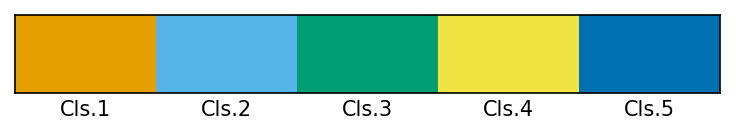

In [7]:
path = files("ace_of_clust").joinpath("resources/default_colors.txt")
default_colors = path.read_text().splitlines()
fig, _, _  = aoc.plot_discrete_colorbar(default_colors[:5], K_max=5)

#### load truth labels
If annotations are available (e.g., ground truth, manual annotations, or reference labels), we load them here to be used in downstream label-based analyses and visualizations.

In [8]:
truth_labels_file = example_data_dir / "clustering" / "kmeans" / "groups.txt"
truth_labels = np.loadtxt(truth_labels_file, dtype=int)
print(pd.Series(truth_labels).value_counts())

0    100
2     80
3     70
1     50
Name: count, dtype: int64


#### load truth X and compute coordinates (via PCA)
We load the clustering input data $X$ if available (e.g., a gene-expression count matrix).

Because our toy dataset has no associated **coordinates**, we compute PCA (via sklearn) and use PC1 and PC2 as coordinates.

For scRNA-seq data, coordinates are typically UMAP embeddings; for spatial transcriptomics, they should be the spatial coordinates. 

The notion of “coordinates” is flexible—it can even be the values of two selected features—and is mainly used to support 2D visualization.

In [9]:
# load truth X and compute PCA (using sklearn) to be used as coordinates
truth_X_file = example_data_dir / "X.txt"
truth_X = np.loadtxt(truth_X_file, delimiter=",")
X_pca = PCA(n_components=2).fit_transform(truth_X)
feature_names = [f"Feature{i+1}" for i in range(truth_X.shape[1])]

#### visualize ground truth labels

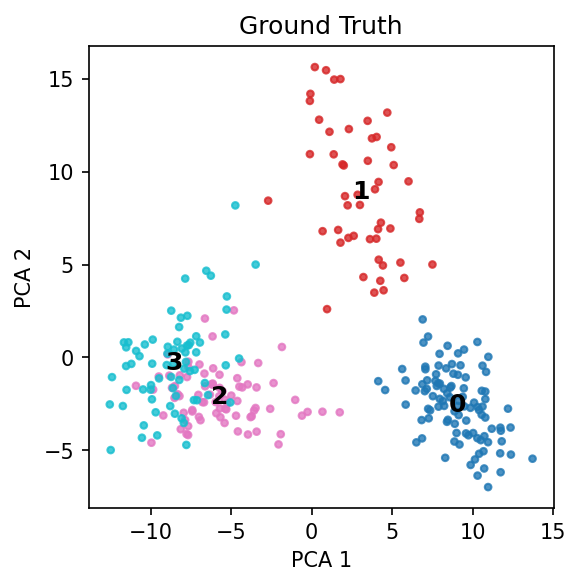

In [10]:
plt.figure(figsize=(4,4), dpi=150)
plt.scatter(X_pca[:,0], X_pca[:,1], c=truth_labels, cmap='tab10', s=10, alpha=0.8)
# label each group in the center
for label in np.unique(truth_labels):
    mask = truth_labels == label
    x_center = X_pca[mask, 0].mean()
    y_center = X_pca[mask, 1].mean()
    plt.text(x_center, y_center, str(label), color='black', fontsize=12, ha='center', va='center', weight='bold')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Ground Truth")
plt.show()

In [11]:
from clumppling.utils import get_uniq_lb_sep
# get group separations based on truth labels
grp_lbs, grp_indices, grp_seps = get_uniq_lb_sep(truth_labels)

#### visualize (some selected) feature value 

This is used to visualize gene counts, etc.

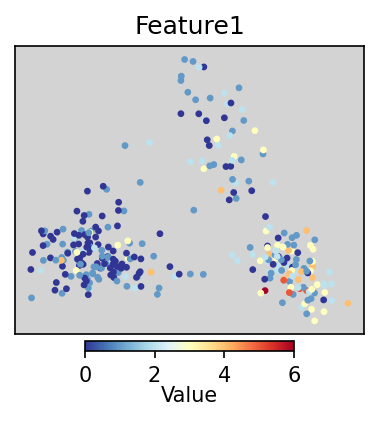

In [12]:
i_g = 0 # first feature
feature_val = truth_X[:, i_g]
fig, ax = plt.subplots(1, 1, figsize=(3,3), dpi=150)
fig = aoc.plot_feature_count(feature_val, X_pca, feature_name=feature_names[i_g], ax=ax,
                             cmap="RdYlBu_r", cbar_label="Value")

### Model 1: KMeans

In [13]:
align_dir = example_data_dir / "aligned" / "kmeans"
cls_dir = example_data_dir / "clustering" / "kmeans"

#### load results

In [14]:
# load clumppling results 
results = aoc.load_clumppling_results(
    align_dir=align_dir,
    suffix="rep",
    cls_dir=cls_dir,
    load_P=False,  
)

# compute pairwise mappings between modes
pair_mappings = aoc.get_mode_pair_mappings(
    mode_names=results.modes,
    all_modes_alignment=results.all_modes_alignment,
    alignment_acrossK=results.alignment_acrossK,
)

We can see the summary statistics of each mode.

In [15]:
results.mode_stats

,Mode,Representative,Size,Cost,Performance
0,K3M1,1_K3R1,5,1.069893e-32,1.000000
1,K4M1,8_K4R3,5,5.266667e-02,0.773355
2,K5M1,11_K5R1,1,0.000000e+00,1.000000
3,K5M2,12_K5R2,1,0.000000e+00,1.000000
4,K5M3,13_K5R3,1,0.000000e+00,1.000000
5,K5M4,14_K5R4,1,0.000000e+00,1.000000
6,K5M5,15_K5R5,1,0.000000e+00,1.000000


Next, let's visualize cluster memberships.

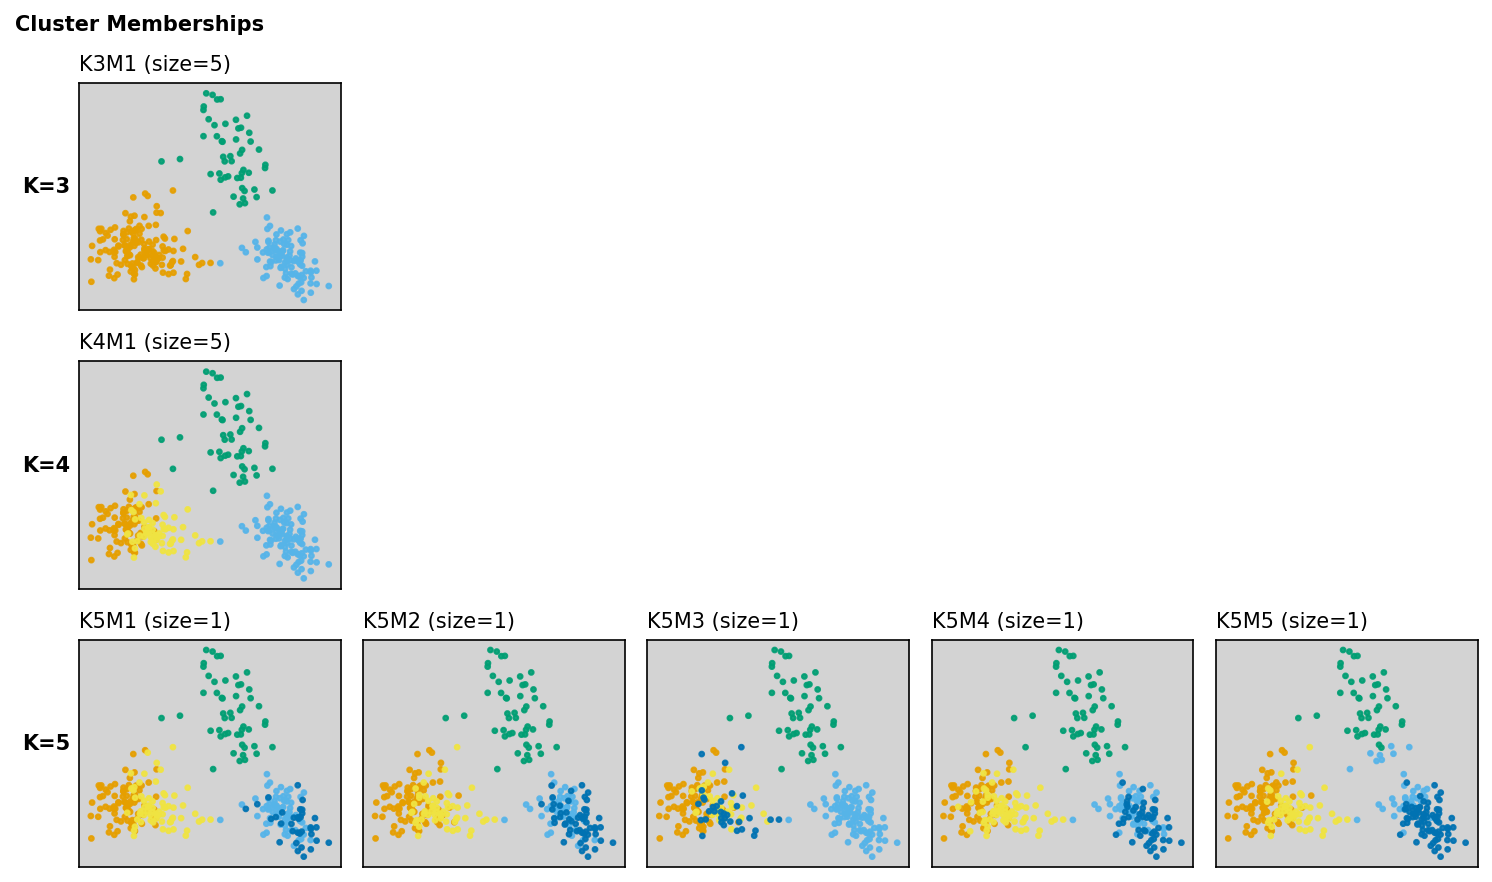

In [16]:
fig, axes = aoc.plot_cluster_overlay(
    results,
    coords=X_pca,
    cluster_colors=default_colors[:results.K_max],
    val_threshold=0.5,
    s=5,
    alpha=0.9,
    suptitle=f"Cluster Memberships",
    suptitle_kwargs= {'y':0.95, 'fontsize':10},
)

Or, if we want to view memberships in bar charts (structure plots) for a more direct visual comparison:

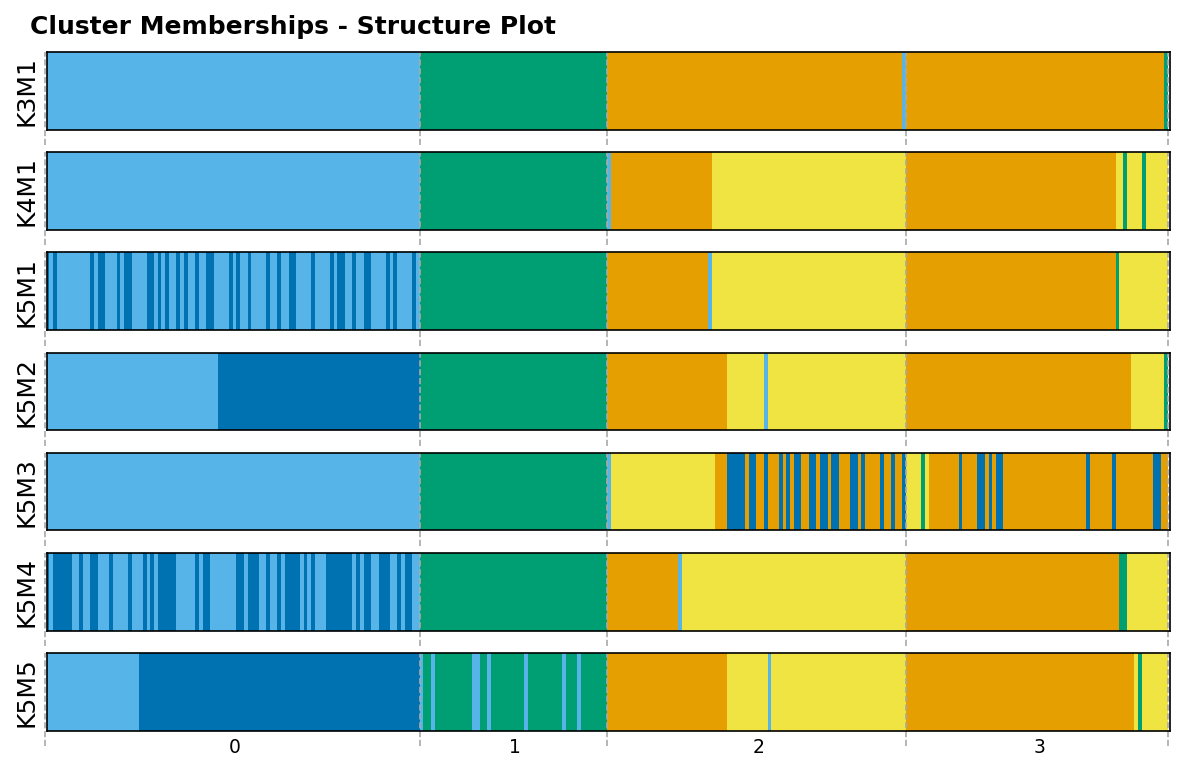

In [17]:
fig = aoc.plot_structure_one_level(
    results,
    cmap=default_colors,
    grp_labels=truth_labels,
    figsize=(8,5),
)
fig.suptitle("Cluster Memberships - Structure Plot", y=1.02, x=0.25, fontsize=12, weight='bold')
pass

### Model 2: NMF

In [18]:
align_dir = example_data_dir / "aligned" / "nmf"
cls_dir = example_data_dir / "clustering" / "nmf"

#### load results and compute feature-level metrics

In [19]:
# load clumppling results (with P matrices)
results = aoc.load_clumppling_results(
    align_dir=align_dir,
    suffix="rep",
    cls_dir=cls_dir,
    load_P=True,  # set to True to load P (for mixed-membership models)
    strict_P=True,   # raises FileNotFoundError if any P file is missing
)

# compute pairwise mappings between modes
pair_mappings = aoc.get_mode_pair_mappings(
    mode_names=results.modes,
    all_modes_alignment=results.all_modes_alignment,
    alignment_acrossK=results.alignment_acrossK,
)

We can see the summary statistics of each mode.

In [20]:
results.mode_stats

,Mode,Representative,Size,Cost,Performance
0,K3M1,1_K3R1,5,1.590216e-14,1.000000
1,K4M1,6_K4R1,5,1.737760e-06,0.998863
2,K5M1,11_K5R1,5,3.120587e-05,0.994993


#### visualize results

We can visualize the Q matrices of each mode.

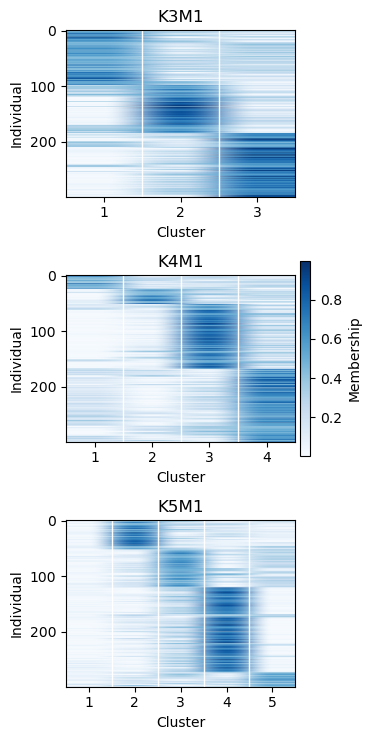

In [21]:
fig, axes = aoc.plot_Q_grid(results, cmap="Blues")
# if to visualize a single mode: aoc.plot_Q_heatmap(results, 'K3M1', cmap="Blues", ax=ax) 

We can also look at cluster sizes (sum of memberships in each cluster) in a specific mode.

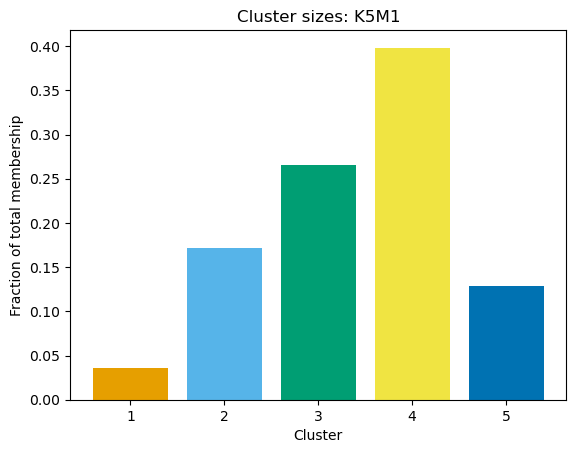

In [22]:
mode = 'K5M1'
fig, ax = aoc.plot_cluster_bars(results, mode, colors=default_colors[:results.mode_K[mode]])

To visualize cluster memberships, we can overlay all clusters on the same scatter plot by applying a membership `val_threshold`.

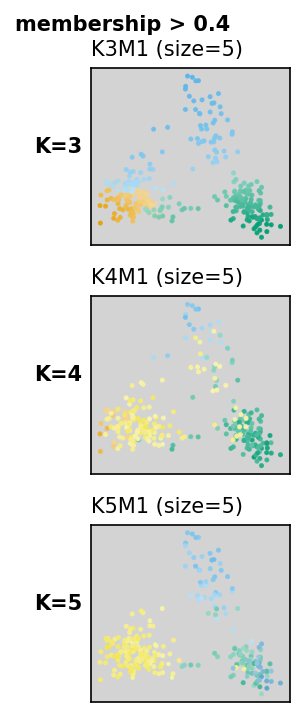

In [23]:
fig, axes = aoc.plot_cluster_overlay(
    results,
    coords=X_pca,
    cluster_colors=default_colors[:results.K_max],
    val_threshold=0.4,
    s=2,
    alpha=0.9,
    suptitle=f"membership > 0.4",
    suptitle_kwargs= {'y':0.92, 'fontsize':10},
    figsize=(2,5)
)

We can also plot each cluster’s membership separately in its own scatter plot.

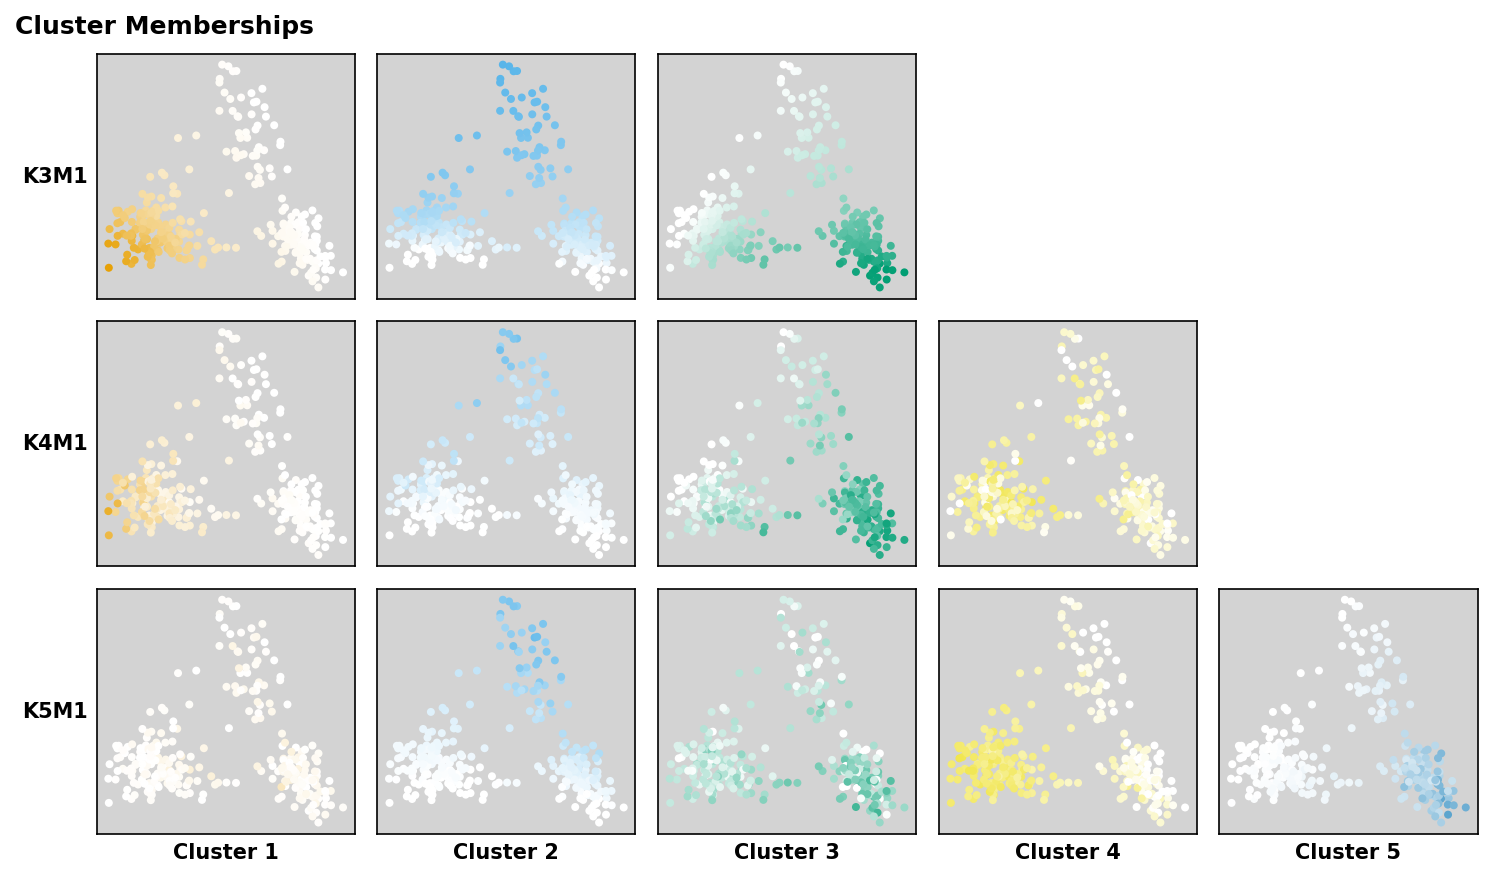

In [24]:
fig, axes = aoc.plot_cluster_panels(
    results,
    coords=X_pca,
    cluster_colors=default_colors[:results.K_max],    # or None → tab20 default
    val_threshold=-1,            # show all memberships
    s=8,
    alpha=1.0,
    suptitle="Cluster Memberships",
    suptitle_kwargs= {'y':0.94, 'fontsize':12},
)

To view a single cluster in a single mode, 

Text(0.5, 1.0, 'K5M1, Cluster 1')

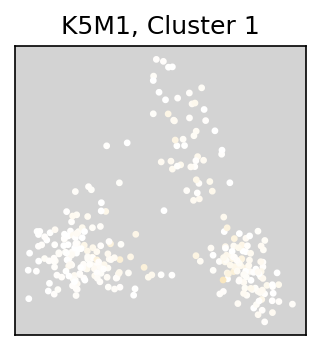

In [25]:
cluster_idx = 0  
Q = results.Q_by_mode[mode]      # shape (n_cells, K)
fig, ax = plt.subplots(1, 1, figsize=(2.5,2.5), dpi=150)
ax, sp = aoc.plot_spatial_membership(
    Q,
    X_pca,
    s=5, alpha=1.0,
    ref_color=default_colors[cluster_idx],   # base color for this cluster
    cls_idx=cluster_idx,
    ax=ax,
)
ax.set_title(f"{mode}, Cluster {cluster_idx + 1}")  # one-based in title


We can also visualize the results (of a single mode) in structure plot.

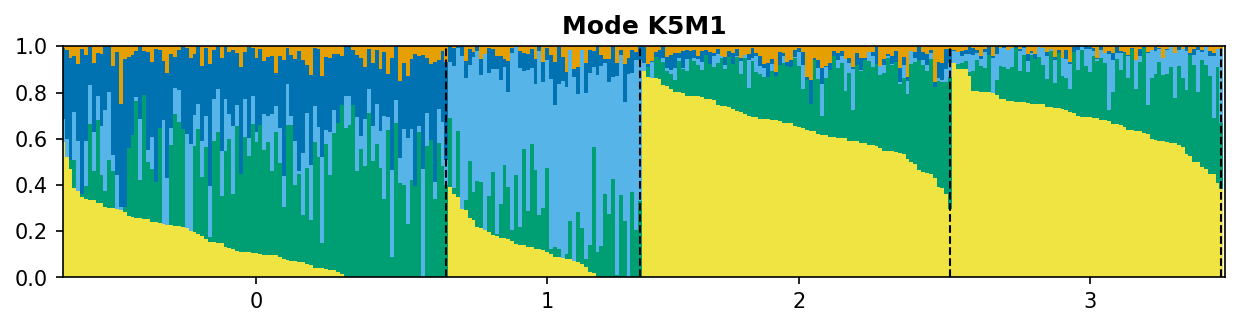

In [26]:
# plot a single membership (in structure bar charts)
fig, ax = plt.subplots(figsize=(10, 2), dpi=150)
# sort individuals within each label group by the largest cluster membership in that group
aoc.plot_membership_reordered(results.Q_by_mode[mode], cmap=default_colors[:results.mode_K[mode]], 
                                     lbs=truth_labels, ax=ax, title="", annot="")
# add vertical lines to separate groups
for sep in grp_seps:
    ax.axvline(x=sep - 0.5, color='black', linestyle='--', linewidth=1)
ax.set_xticks(grp_indices)
ax.set_xticklabels(grp_lbs)
ax.set_title(f"Mode { mode }", fontsize=12, weight='bold')
pass

To view that of all modes,

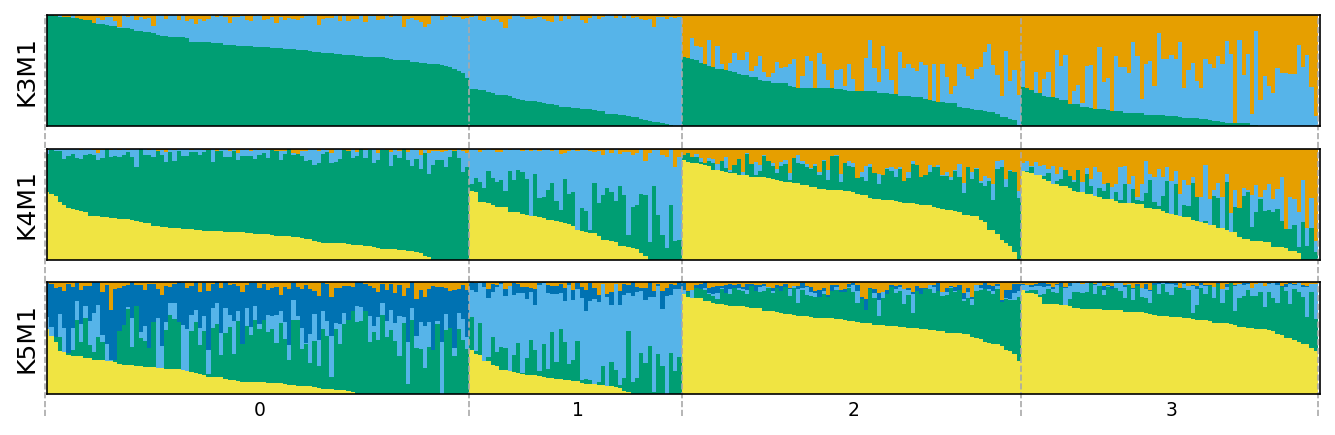

In [27]:
fig = aoc.plot_structure_one_level(
    results,
    cmap=default_colors[:results.K_max],
    grp_labels=truth_labels,    # labels
    lb_suffix_sep="_",
    reorder_clsind=True,
)

We can use *Clumppling*'s function to plot the alignment graph.

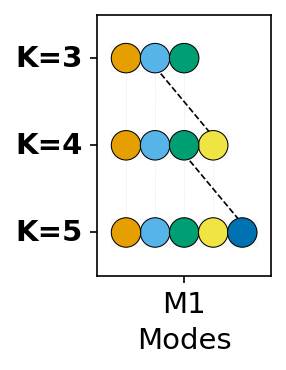

In [28]:
from clumppling.plot import plot_alignment_graph

fig = plot_alignment_graph(results.K_range, names_list=results.mode_names_list, cmap=default_colors[:results.K_max], 
                           alignment_acrossK=results.alignment_acrossK, all_modes_alignment=results.all_modes_alignment,
                           alt_color=False, ls_alt=['-', '--'])

#### subset to selected modes
Sometimes we want to focus on a selected subset of modes. We can create a new `ClumpplingResults` object by the following.

In [29]:
# pick a subset
modes_subset = ['K3M1', 'K4M1']
sub = aoc.subset_results(results, modes_subset)

Previous visualizations and analyses can be similarly performed on this subset.

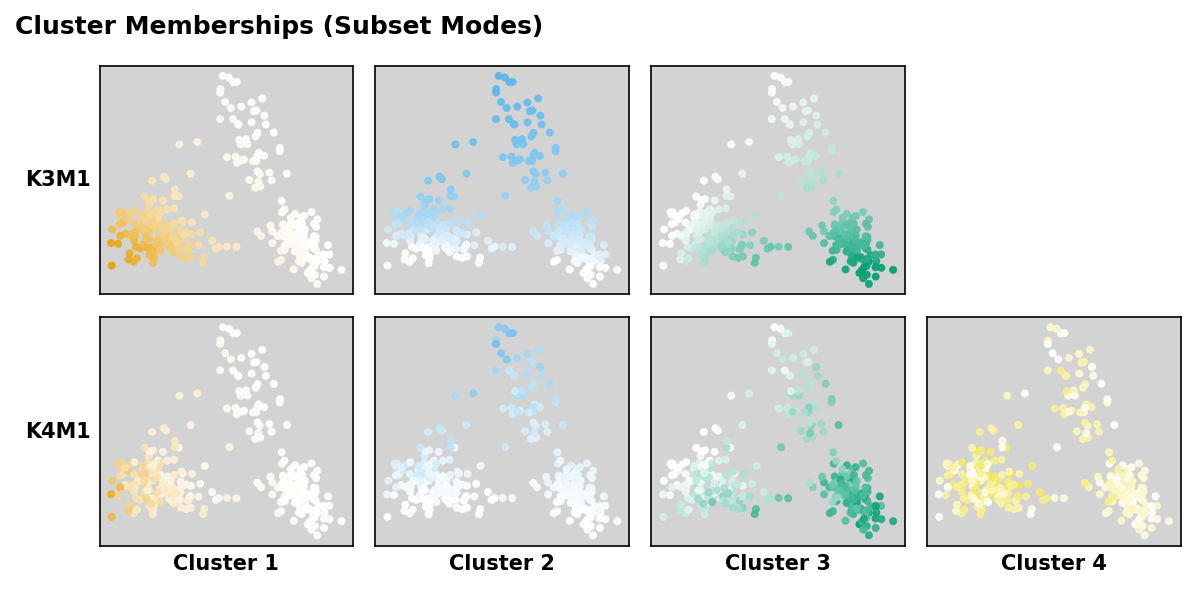

In [30]:
fig, axes = aoc.plot_cluster_panels(
    sub,
    coords=X_pca,
    cluster_colors=default_colors[:sub.K_max],    # or None → tab20 default
    val_threshold=-1,            
    s=8,
    alpha=0.9,
    suptitle="Cluster Memberships (Subset Modes)",
    suptitle_kwargs= {'y':0.93, 'fontsize':12},
)

We can also put scatter plot and structure plot together.

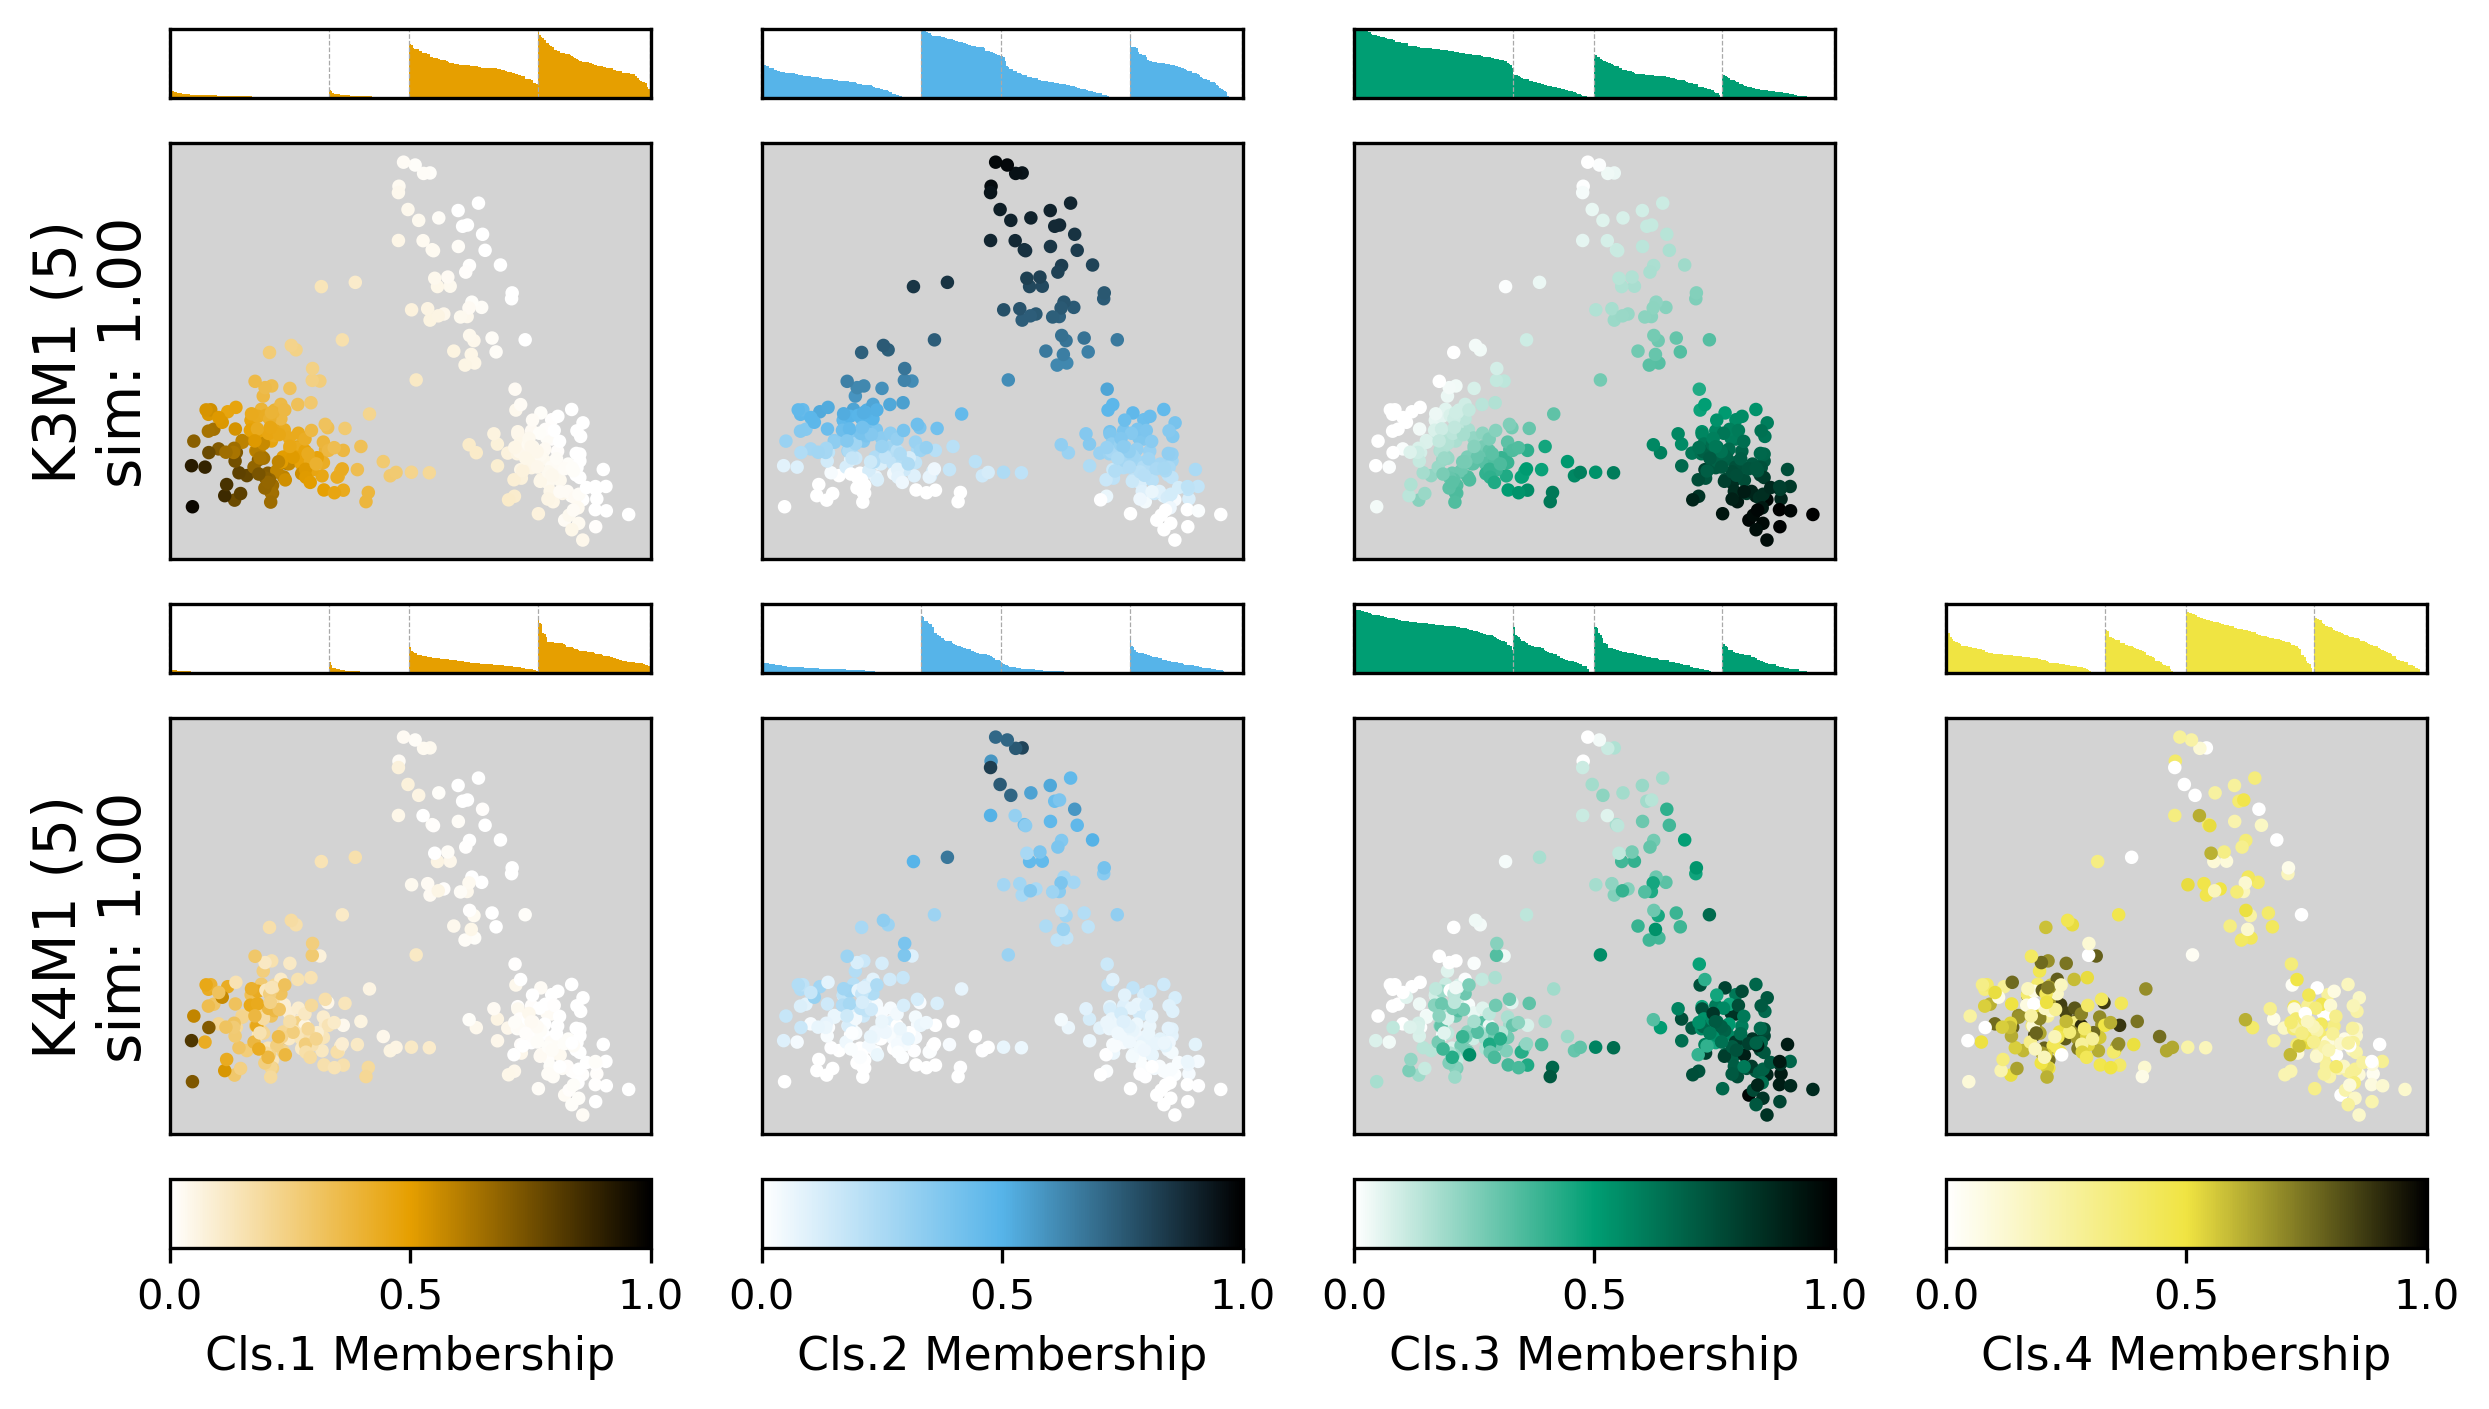

In [31]:
fig = aoc.plot_spatial_structure_grid(
    sub,
    X_pca,
    grps=truth_labels,
    cmap=default_colors[:sub.K_max],
    reorder_cls=True,
    s=5,
    dpi=300,
)

#### perform feature-level analysis
This is only feasible for mixed-membership clustering, where there are $G$ features used in clustering and the *P* matrices (of size $G\times K$) provide feature-level signals in clustering.

In [32]:
# compute per-gene metrics for all modes
df_by_mode = aoc.compute_all_feature_metrics(results, feature_names=feature_names)

# select top features by weighted_Psum quantile across all modes 
selected_by_mode, df_selected_all, overlap = aoc.select_top_features(
    df_by_mode,
    top_quantile=0.5,
)


Let's take a look at the feature metrics for one mode.

In [33]:
df_by_mode['K4M1'].head()

,weighted_Psum,sepLFC,sepCls
Feature1,0.005905,24.446164,"((3,), (0, 1, 2))"
Feature2,0.005582,3.805408,"((1,), (0, 3, 2))"
Feature3,0.003793,25.712823,"((2,), (3, 1, 0))"
Feature4,0.007891,25.627609,"((3,), (0, 1, 2))"
Feature5,0.001886,22.769567,"((3,), (2, 1, 0))"


We provide a function to plot feature metrics (by default, `x='weighted_Psum'` against `y='sepLFC'`) as a simple scatter plot. 

In this function, `x` and `y` can be set to other column names if additional metrics have been added to the dataframe and you’d like to plot them.

Additionally, we can highlight a few features of interest in this scatter plot.

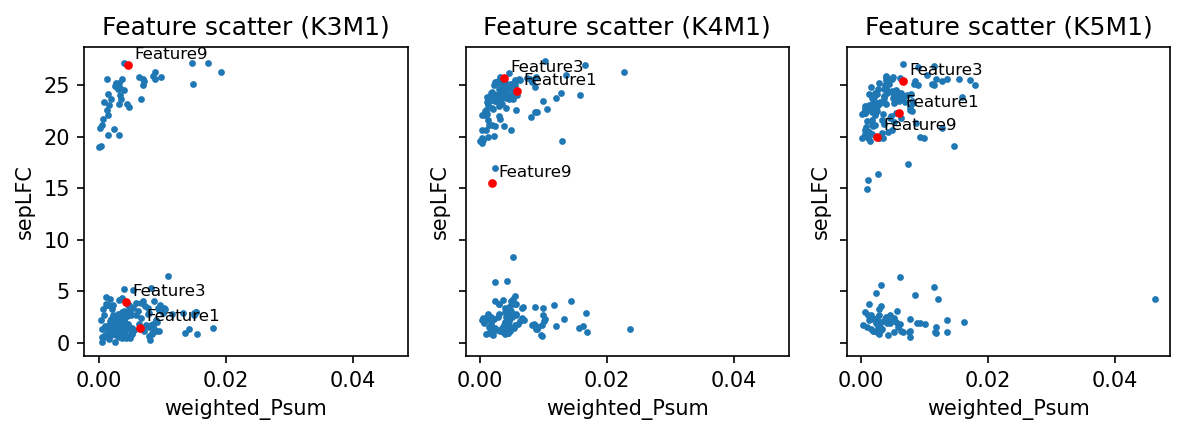

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(8,3), dpi=150, sharex=True, sharey=True)
aoc.plot_feature_scatter(df_by_mode['K3M1'], mode_name='K3M1', 
                                   ax=axes[0], highlight=['Feature1', 'Feature3', 'Feature9'])
aoc.plot_feature_scatter(df_by_mode['K4M1'], mode_name='K4M1', 
                                   ax=axes[1], highlight=['Feature1', 'Feature3', 'Feature9'])
aoc.plot_feature_scatter(df_by_mode['K5M1'], mode_name='K5M1', 
                                   ax=axes[2], highlight=['Feature1', 'Feature3', 'Feature9'])
fig.tight_layout()
pass

We can get top features by some metric (default: `metric='weighted_Psum'`).

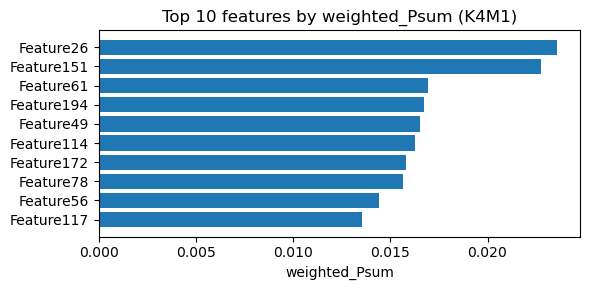

In [35]:
fig, ax = aoc.plot_feature_bar(df_by_mode['K4M1'], mode_name='K4M1', top_n=10)

We can obtain "clustering-informative candidates" from outliers features in the joint distribution of these feature metrics.

In [36]:
mode = 'K4M1'
outliers_features, outliers_mask = aoc.get_kde_outliers(
    df_by_mode[mode],
    x_col=f"weighted_Psum",
    y_col=f"sepLFC",
    levels=8,
    min_x=0.0,
    return_mask=True,
    cut=0,
)
print("Number of outliers detected:", len(outliers_features))
outliers_features

Number of outliers detected: 5


,weighted_Psum,sepLFC,sepCls
Feature26,0.023579,1.394149,"((0,), (1, 2, 3))"
Feature49,0.016508,27.006106,"((0,), (3, 1, 2))"
Feature119,0.009842,0.712435,"((1, 0, 2), (3,))"
Feature151,0.022758,26.341207,"((1,), (0, 3, 2))"
Feature172,0.015819,24.057360,"((0,), (3, 1, 2))"


Number of outliers with sepLFC>1: 4


Text(25.58333333333333, 0.5, 'sepLFC')

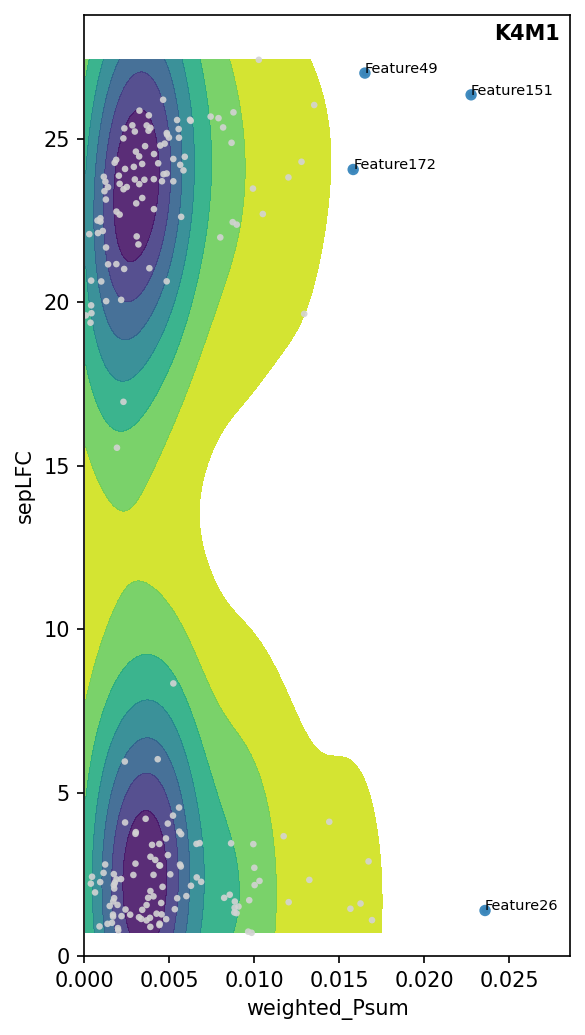

In [37]:
# plot outliers
outliers_mask &= (selected_by_mode[mode][f"sepLFC_{mode}"]>1)
print(f"Number of outliers with sepLFC>1: {np.sum(outliers_mask)}")
fig, ax = aoc.plot_feature_kde(
    df_by_mode[mode],
    x_col=f"weighted_Psum",
    y_col=f"sepLFC",
    mode_name=mode,
    levels=8,
    outlier_mask=outliers_mask,
    bg_alpha=0.9,
)
ax.set_xlabel("weighted_Psum")
ax.set_ylabel("sepLFC")


We can also list top features for all modes.

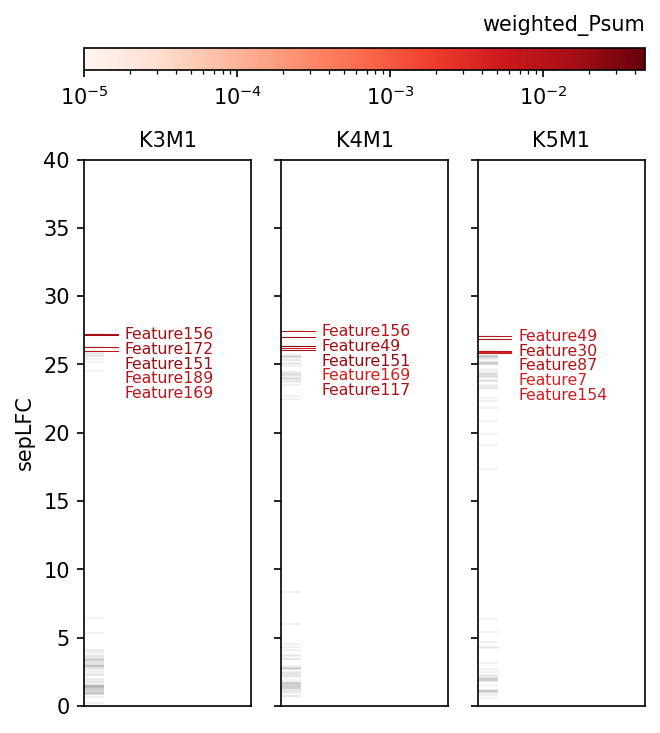

In [38]:
modes = results.modes  # or a subset like ["K21M1", "K25M2", ...]

fig, axes_by_mode = aoc.plot_sepLFC_labels(
    df_selected_all,
    modes,
    sepLFC_threshold=0.0,
    figsize_scale=1.5,
    n_top_lo=5,
)

#### focus on a specific feature
First, let's add a gray color to our palette to be used for "multiple clusters separated".

In [39]:
custom_palette = {'Cls.{}'.format(i_c+1):c for i_c,c in enumerate(default_colors[:results.K_max])}
custom_palette['Multi.Cls'] = '#A9A9A9'

Next, let's plot the feature metrics of a clustering-informative feature we previously highlighted.

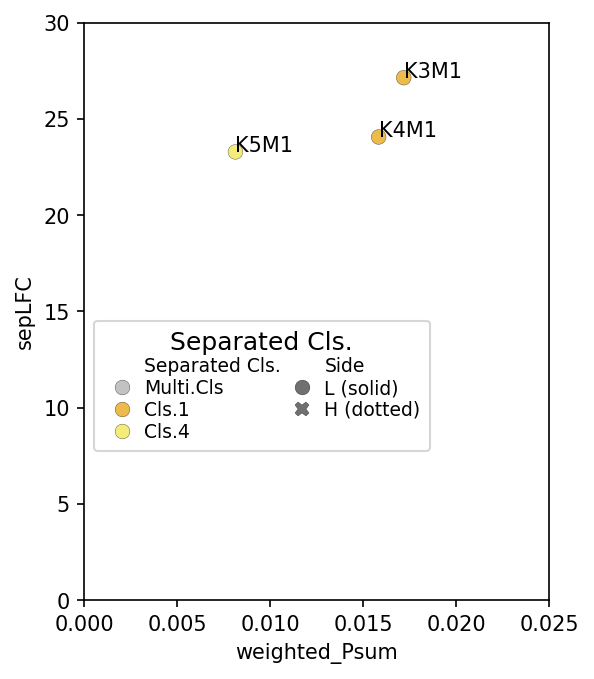

In [40]:
focal_feature = "Feature172"
modes = results.modes

fig, ax = plt.subplots(figsize=(4,5), dpi=150)
_, _, df_gene = aoc.plot_feature_across_modes(
    df_pvs_modes=df_by_mode,
    modes=modes,
    selected_feature=focal_feature,
    custom_color_dict=custom_palette,
    xlim=[0.0, 0.025],
    ylim=[30],
    legend_loc="upper left",
    legend_bbox_to_anchor=(0.0, 0.5),
    ax=ax
)

We can also see which clusters it's separating.

Text(0.5, 0.95, 'Separated clusters')

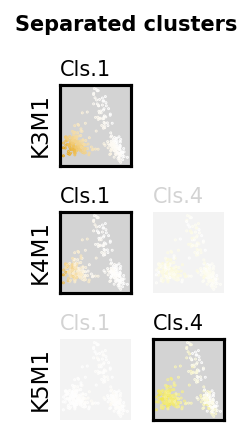

In [41]:
fig, axes = aoc.plot_feature_cluster_panels(
    results=results,      
    coords=X_pca,
    df_pvs_modes=df_by_mode,
    selected_feature=focal_feature,
    modes=modes,                 
    colors=default_colors,          
    plot_both_sides=False,       
    val_threshold=0.0,
    w_scale=0.8, h_scale=1.0,
)
fig.suptitle("Separated clusters", fontsize=10, weight='bold', y=0.95)

We can also plot all clusters and how they are separated by this feature.

Text(0.5, 0.97, 'Separated clusters for Gene Feature172')

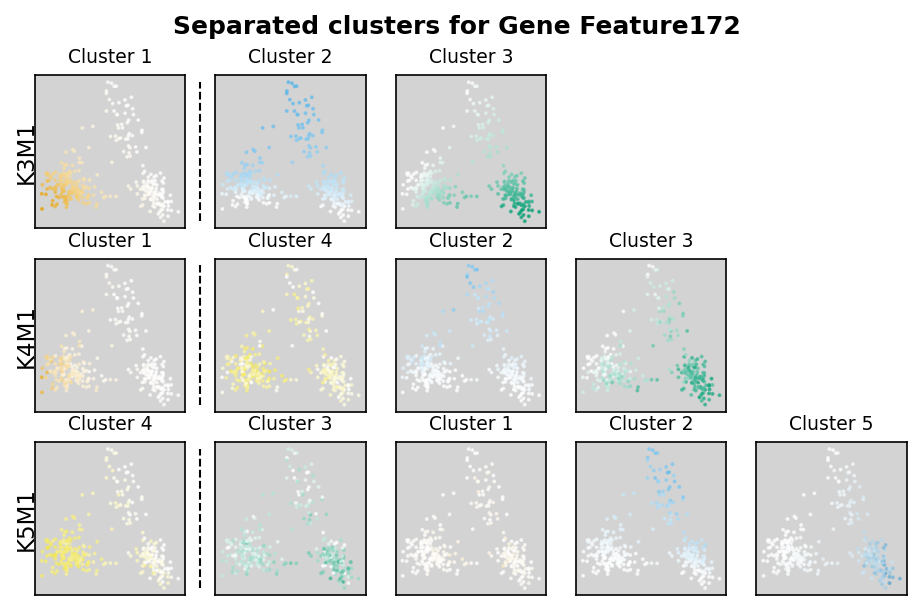

In [42]:
fig, axes = aoc.plot_feature_cluster_panels(
    results=results,      
    coords=X_pca,
    df_pvs_modes=df_by_mode,
    selected_feature=focal_feature,
    modes=modes,                 
    colors=default_colors,         
    plot_both_sides=True,       
    val_threshold=0.0,
    h_scale=1.5,
    w_scale=1.5,
)
fig.suptitle(f"Separated clusters for Gene {focal_feature}", y=0.97, fontsize=12, weight='bold')



It's also helpful to look at the feature value of this feature.

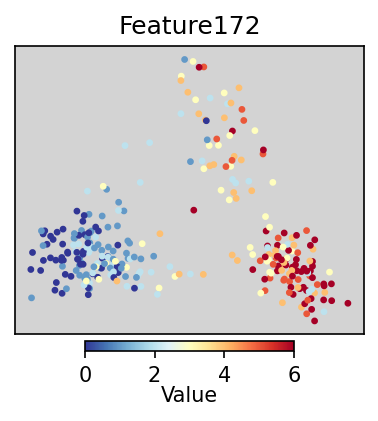

In [43]:
i_g = feature_names.index(focal_feature)
feature_val = truth_X[:, i_g]
fig, ax = plt.subplots(1, 1, figsize=(3,3), dpi=150)
fig = aoc.plot_feature_count(feature_val, X_pca, feature_name=feature_names[i_g], ax=ax,
                             cmap="RdYlBu_r", cbar_label="Value")

### Comparison of Multiple Models

In [44]:
# Load the comparison results
comp_res = aoc.load_compmodels_results(
    res_dir=model_comp_output_dir,
    input_dir=model_comp_dir,
)

# Extract mode-pair mappings across all models
pair_mappings = aoc.get_mode_pair_mappings(
    mode_names=comp_res.full_mode_names,
    all_modes_alignment=comp_res.all_modes_alignment,
    alignment_acrossK=comp_res.alignment_across_all,
)

# Display names of all modes
print(f"Loaded {len(comp_res.full_mode_names)} aligned modes from {len(comp_res.models)} models.")
models = comp_res.models
for model in models:
    print(f" Model: {model}")
    print("\t", comp_res.modes_by_model[model])

[load_compmodels_results] Warning: mode_stats file not found for model 'ground.truth': /oscar/data/sramacha/users/xliu293/ace-of-clust/examples/data/toy/comp_models/toy/ground.truth_mode_stats.txt
Loaded 14 aligned modes from 4 models.
 Model: ground.truth
	 ['ground.truth']
 Model: kmeans
	 ['K3M1', 'K4M1', 'K5M1', 'K5M2', 'K5M3', 'K5M4', 'K5M5']
 Model: lda
	 ['K3M1', 'K4M1', 'K5M1']
 Model: nmf
	 ['K3M1', 'K4M1', 'K5M1']


#### plot aligned clusteirng results
Here, we plot cluster memberships on a 2D scatter plot (here using PCA coordinates), with colors indicating clusters.

By setting `val_threshold`, we only display/color points whose membership exceeds the threshold. For hard clustering, any value in (0,1) works (typically $>10^{−6}$); for mixed-membership clustering, this threshold controls plot density and overlap and should be chosen accordingly. We recommend $0.1–0.5$.

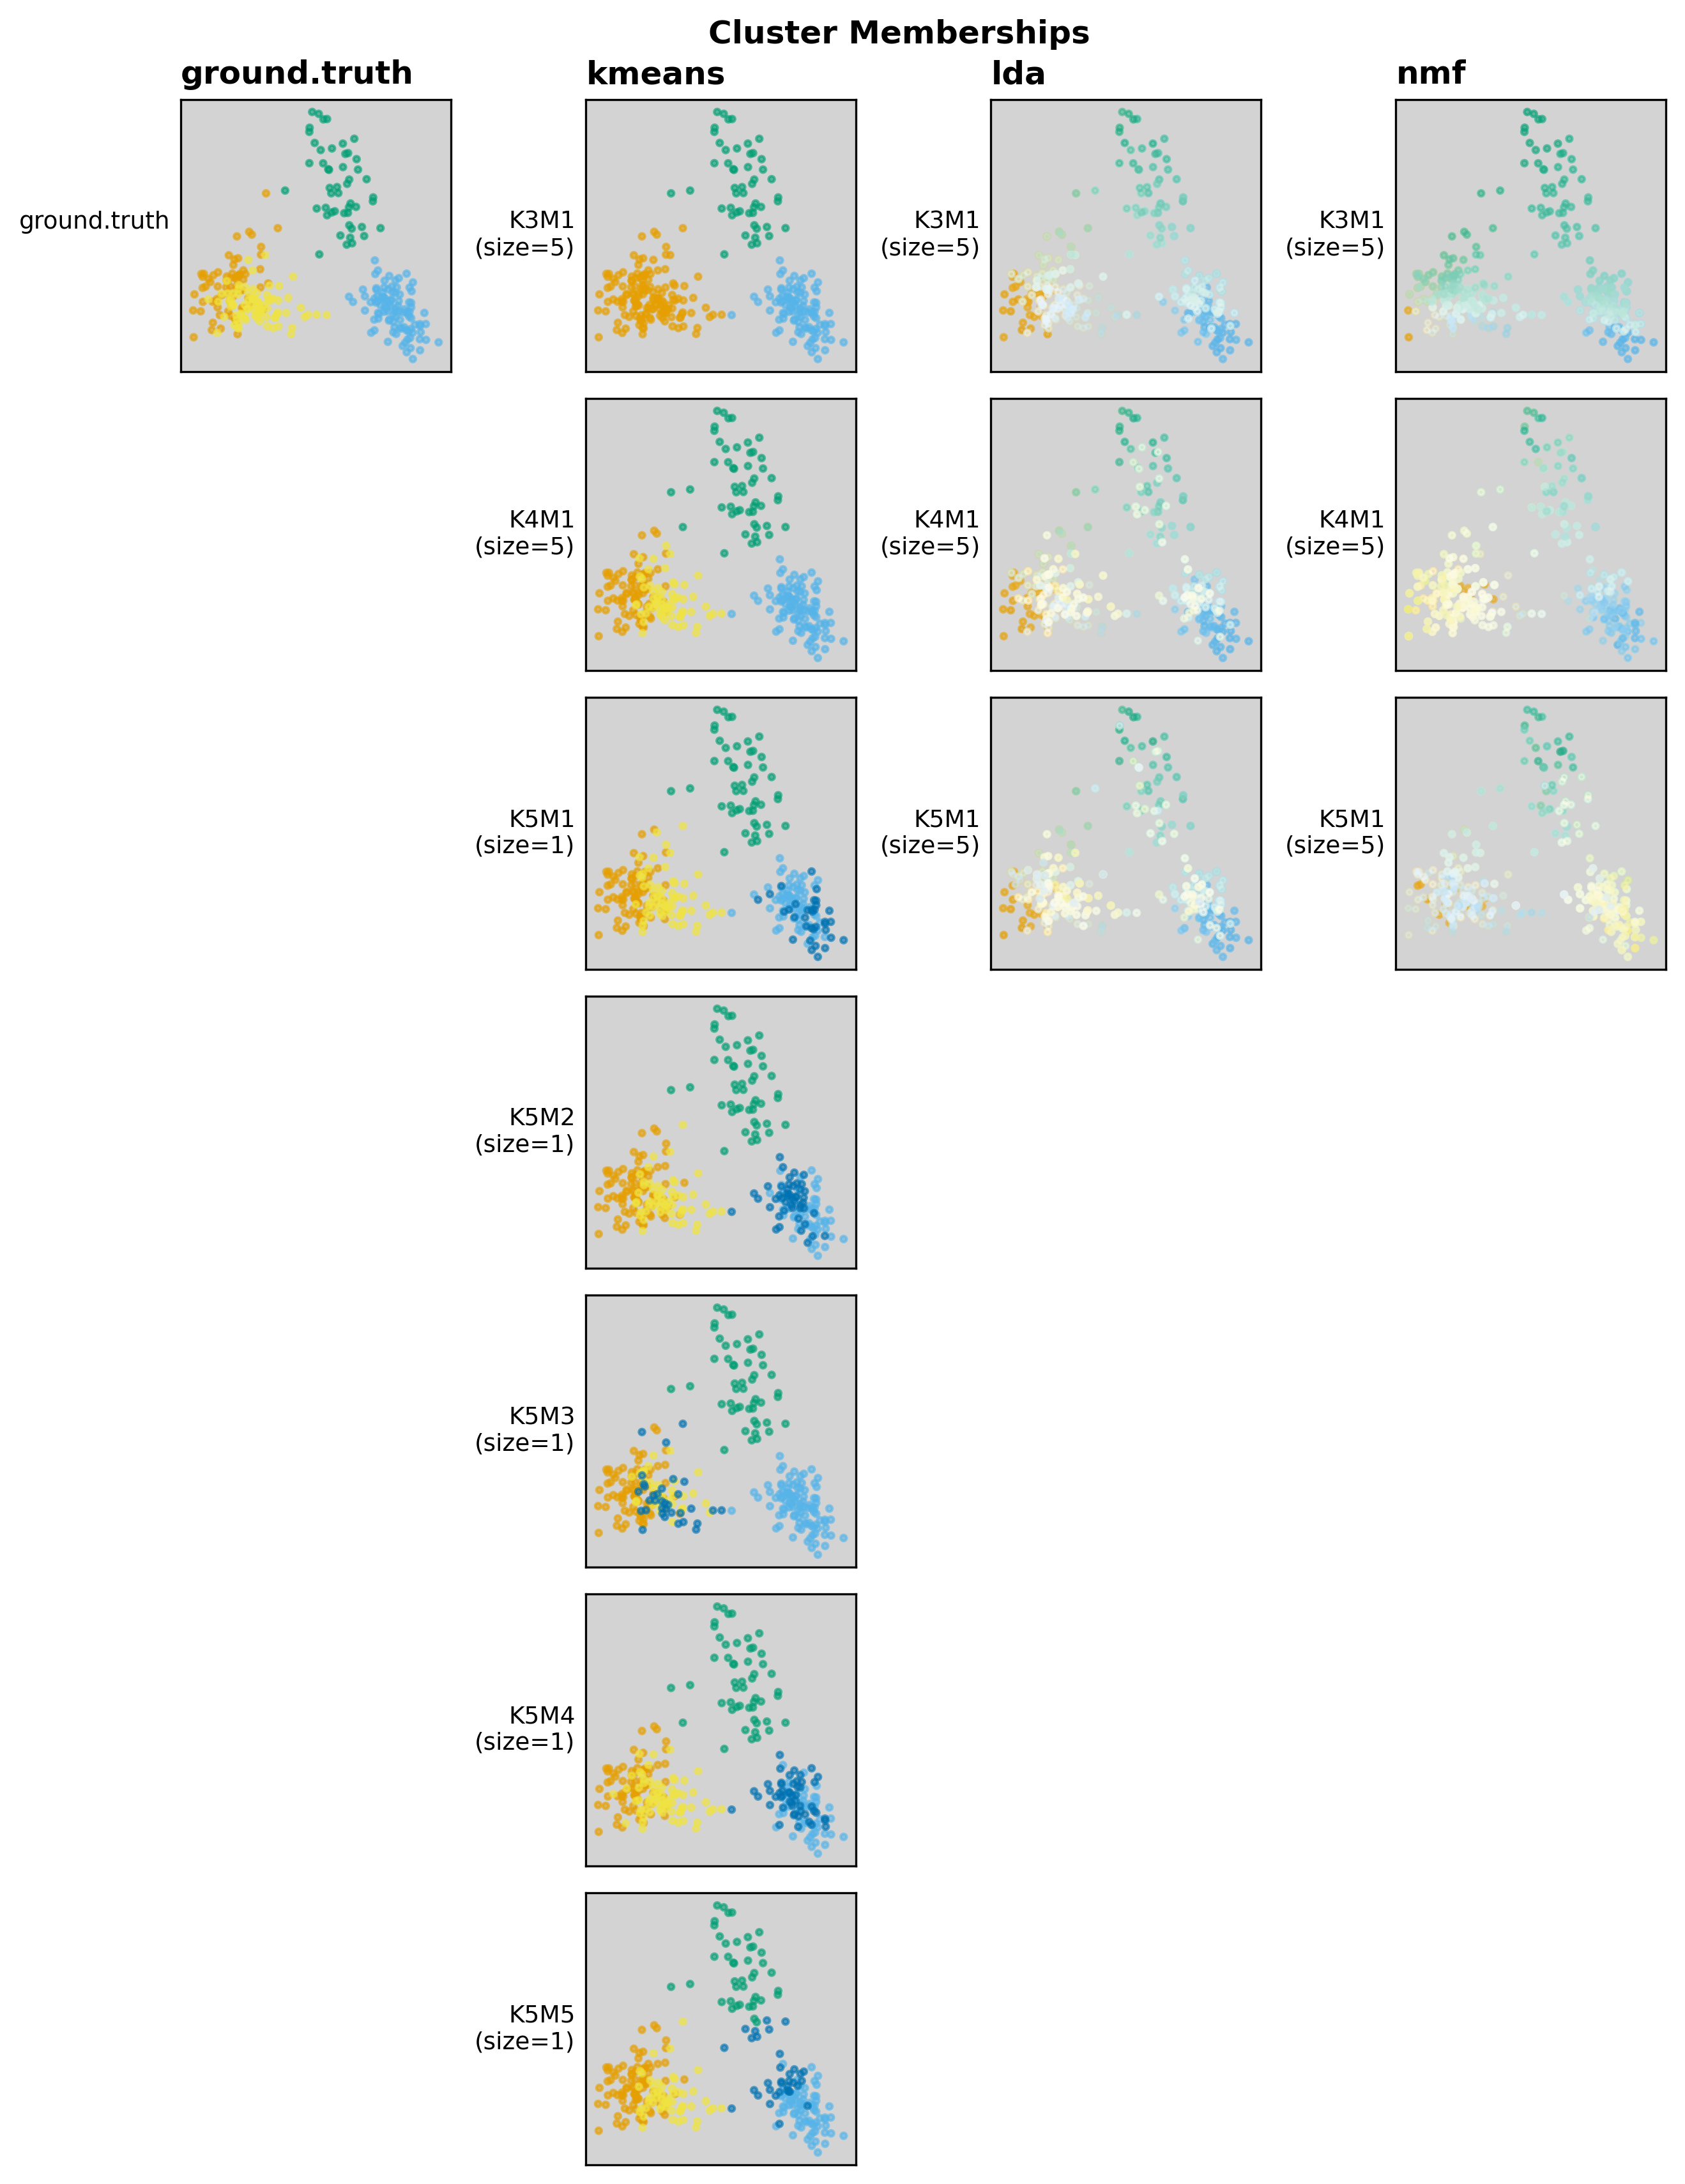

In [45]:
# all modes
fig, ax = aoc.plot_compmodels_Q_grid(
    comp_res,
    X_pca, # coordinates for scatter plot
    colors=default_colors[:comp_res.K_max],
    val_threshold=0.1, # only plot points with membership values above this threshold
    suptitle="Cluster Memberships",
    y_suptitle=0.91,
    s=5, 
    models_plot_order=models,
)

We can also highlight points whose clustering differs substantially from a reference mode (specified by `ref_mode`). 

With `diff_threshold`, we display only points whose membership differences exceed this value.

Comparing to ground.truth_ground.truth


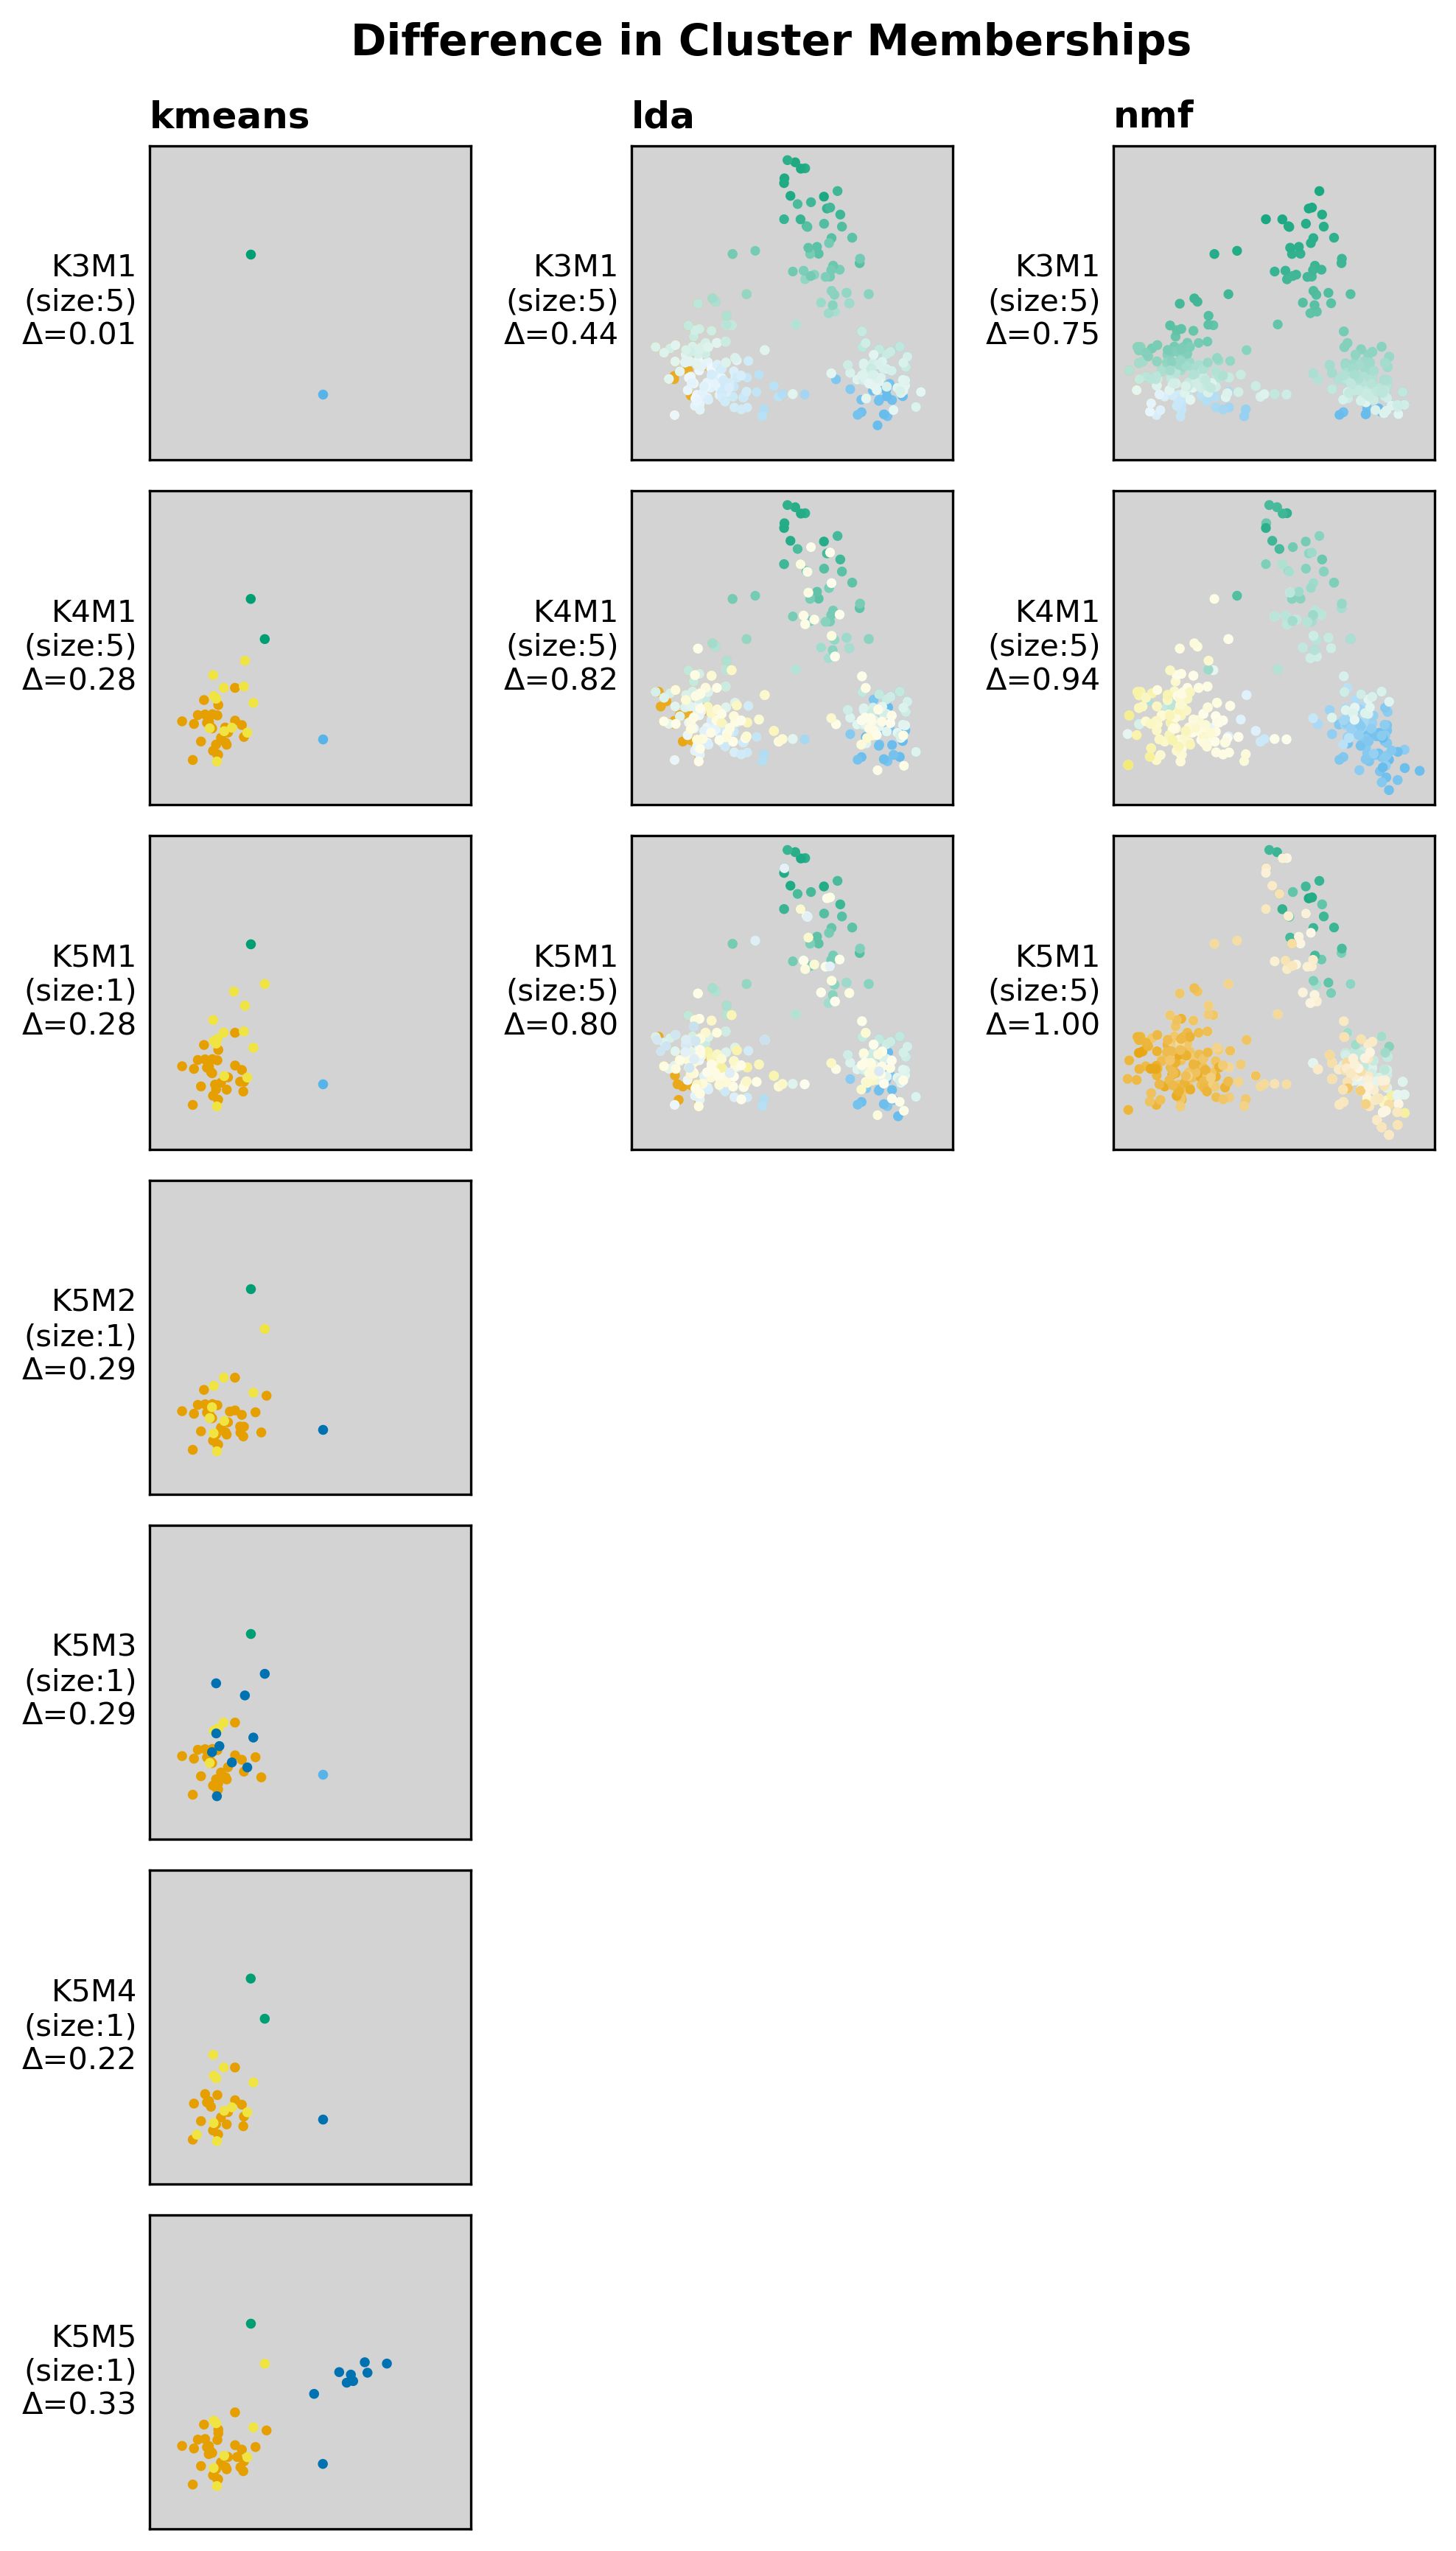

In [46]:
ref_mode = "ground.truth_ground.truth"
print(f"Comparing to {ref_mode}")

fig_diff, axes_diff = aoc.plot_compmodels_diff_grid(
    comp_res=comp_res,
    pair_mappings=pair_mappings,
    coords=X_pca,
    ref_mode=ref_mode, # the full name of the reference mode to compare to
    models_plot_order=models[1:],  # exclude ground truth from the diff plots
    diff_threshold=0.1, # only plot points with differences above this threshold
    val_threshold=0.1, # only plot points with reference membership values above this threshold
    colors=default_colors[:comp_res.K_max],
    s=5, alpha=0.9,  # point size and transparency
    suptitle="Difference in Cluster Memberships",
    y_suptitle=0.92,
)

Instead of all modes, we can also visualize a subset of selected modes. Here, we choose to plot all major modes (the one with largest number of runs in each model).

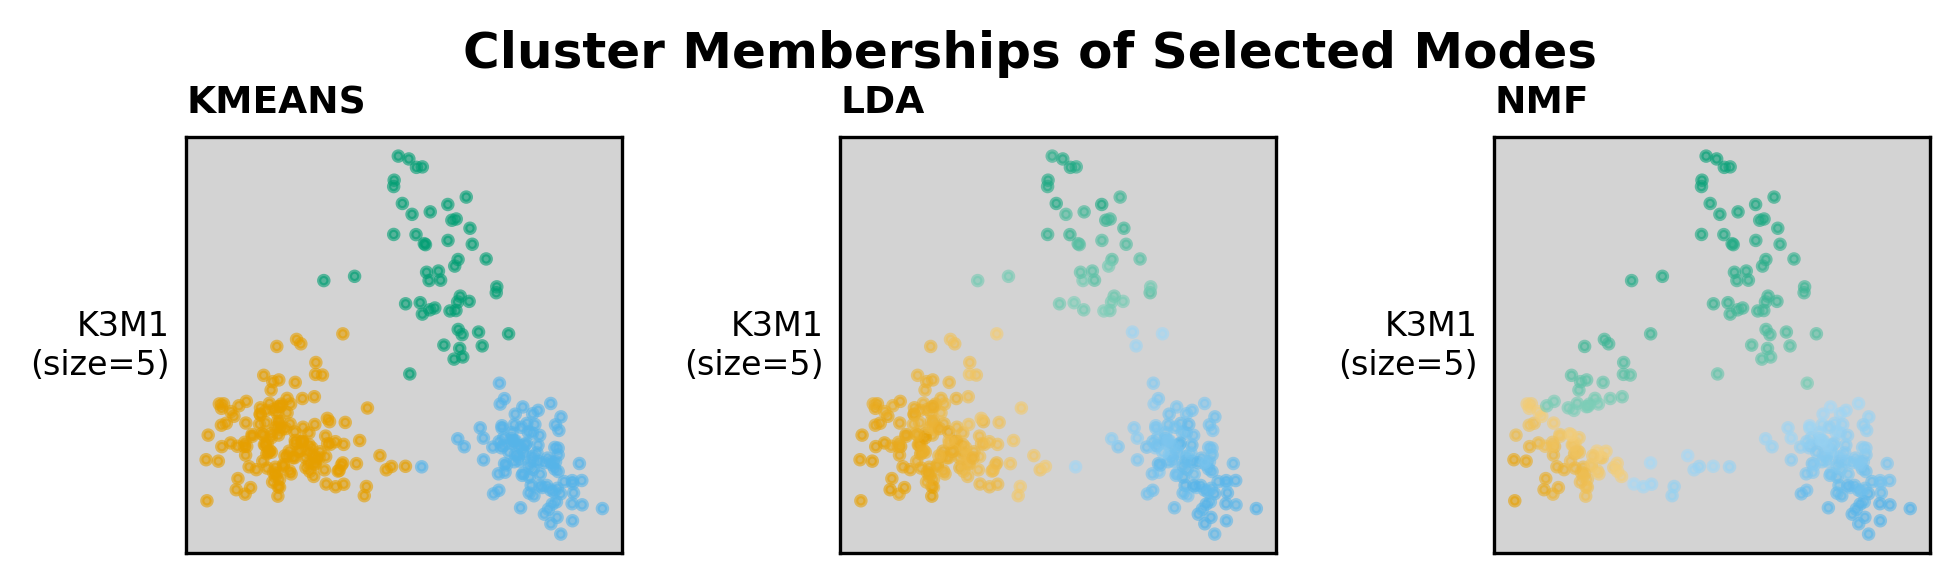

In [47]:
# get the major mode (with largest size) from each model
modes_to_plot = list()
for model in models[1:]:  # skip ground truth
    major_mode = comp_res.mode_stats_by_model[model].sort_values(by='Size', ascending=False).index.values[0]
    modes_to_plot.append((model, major_mode))

fig, axes = aoc.plot_compmodels_Q_selected(
    comp_res,
    X_pca,
    model_mode_list=modes_to_plot,
    n_rows=1,          # number of rows in the plot grid
    colors=default_colors,  
    suptitle="Cluster Memberships of Selected Modes",
    y_suptitle=1.08,
    figsize_scale=(2.5,1.8),
    s=5,
)
# update individual titles
for model, mode in modes_to_plot:
    axes[(model, mode)].set_title(model.upper(), fontsize=9, weight='bold', loc='left')

We use the alignment pattern graph to track how clusters are aligned across modes and models.

(-5.0, 26.5)

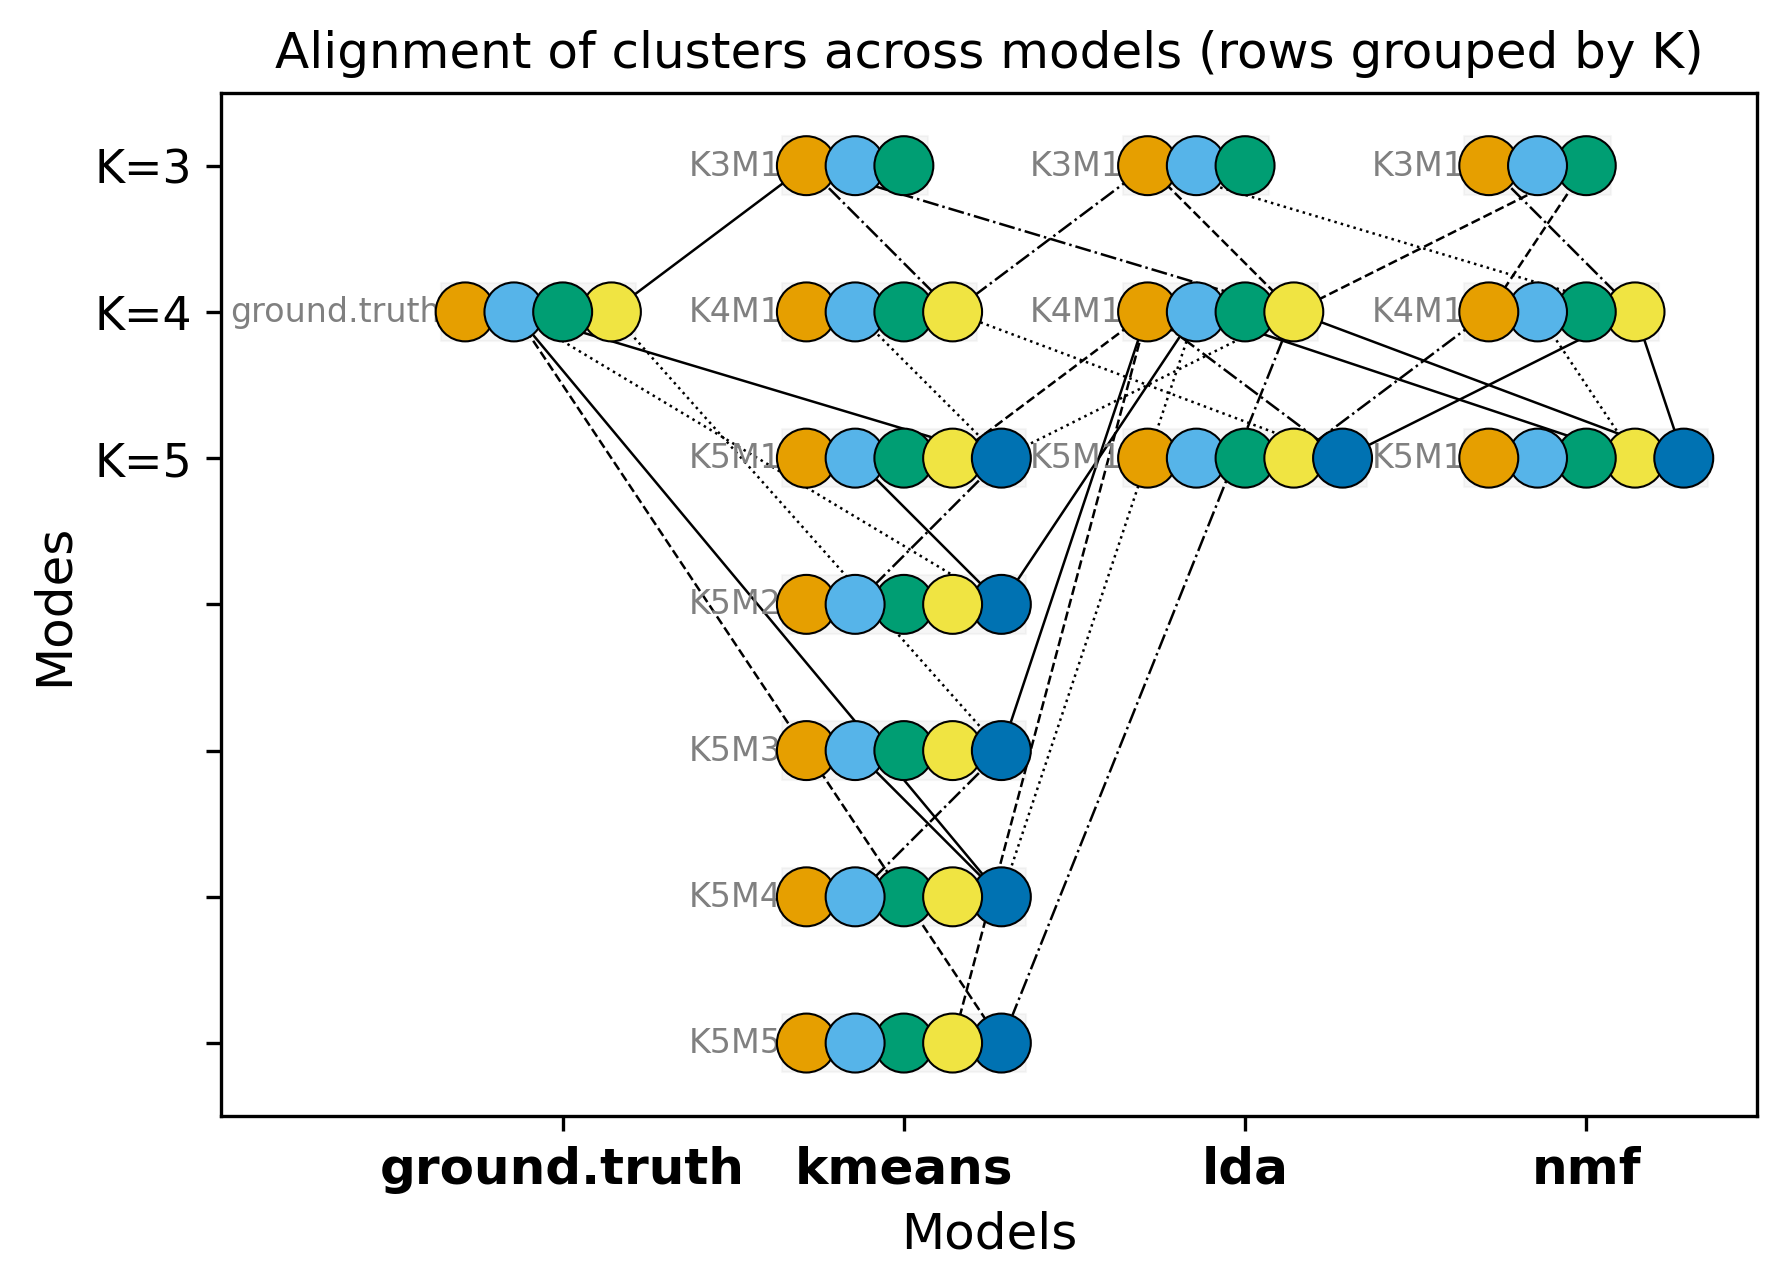

In [48]:
fig, ax = aoc.plot_compmodels_alignment_by_model(
    comp_res,
    cmap=default_colors[:comp_res.K_max],
    pair_mappings=pair_mappings,
    connect_identity=False,  # only highlight non-1–1 / shifted alignments
    adjacent_only=True,      # only between neighboring model columns
    label_modes=True,   # show mode names on the corner
    alt_ls=True, ls_alt=("-", "--", ":", "-."), lw=0.6, # line styles for different K
    figsize_scale=(0.3, 3),
    wspace_padding=1.5,
    dpi=300,
    row_by_K=True, # put modes with same K in the same row
    models_plot_order=models,
)

# update y labels and titles
ax.set_yticklabels(['K=3', 'K=4', 'K=5', '', '', '', ''], fontsize=11)
ax.set_ylabel("Modes", fontsize=12)
ax.set_xlim([-5, None])


If coordinates are unavailable—or if you prefer not to visualize in 2D—we can instead show clustering results as a **structure plot** (stacked bar charts).

*Note: This can be slow for large datasets. If your notebook is memory-limited, use with caution.*

In [49]:
from clumppling.plot import plot_membership

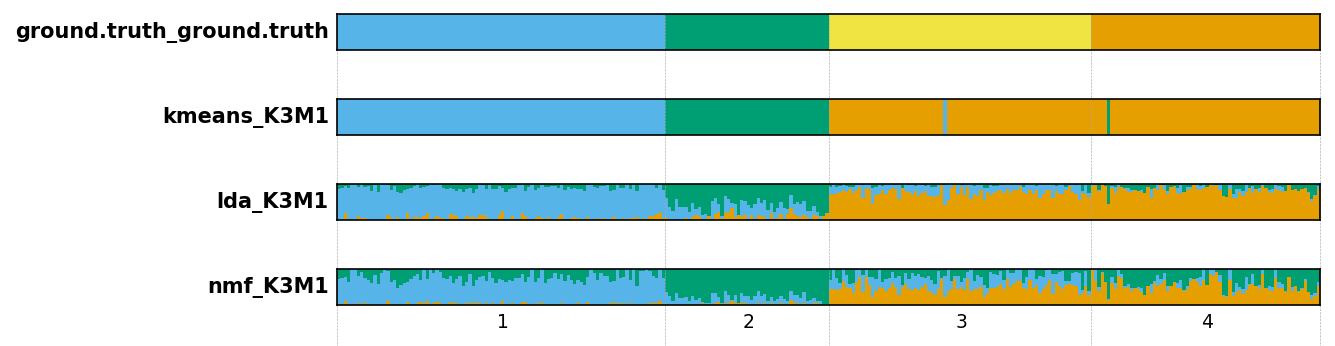

In [50]:
# add ground truth to the modes to plot
modes_to_plot.insert(0, ('ground.truth', 'ground.truth'))

fig = plt.figure(figsize=(9,len(modes_to_plot)*0.7), dpi=150)
gs = fig.add_gridspec(len(modes_to_plot)+1, 1, width_ratios=[1])

for i, mode in enumerate(modes_to_plot):
    mode_full_name = f"{mode[0]}_{mode[1]}"
    ax_membership = fig.add_subplot(gs[i])
    # get aligned Q matrix for the mode
    alignedQ = comp_res.Q_by_mode[mode_full_name]
    
    # plot membership as stacked barplot (structure plot)
    plot_membership(alignedQ, default_colors, ax=ax_membership, ylab="", title="", fontsize=14)
    # use the mode full name as y label
    ax_membership.set_ylabel(mode_full_name, fontsize=10, weight='bold', rotation=0, ha='right', va='center')

    # add vertical lines to separate groups based on the cell-reorder reference  mode
    for v in grp_seps:
        ax_membership.axvline(v, ymin=-1.5, ymax=1, color='darkgray', ls='--', lw=0.3, clip_on=False)
    if i==len(modes_to_plot)-1:
        for v in grp_seps:
            ax_membership.set_xticks(grp_indices)
            ax_membership.set_xticklabels(np.arange(len(grp_lbs))+1, fontsize=9, rotation=0)
            ax_membership.tick_params(axis='x', length=0)  
    
fig.tight_layout()


We can similarly visualize the difference in cluster memberships in structure plots.

In [51]:
# compute difference matrices against reference mode
mat_diffs = aoc.get_diff_matrices(
    comp_res,
    pair_mappings,
    ref_mode=ref_mode,
    strict_pair_mapping=True,
)

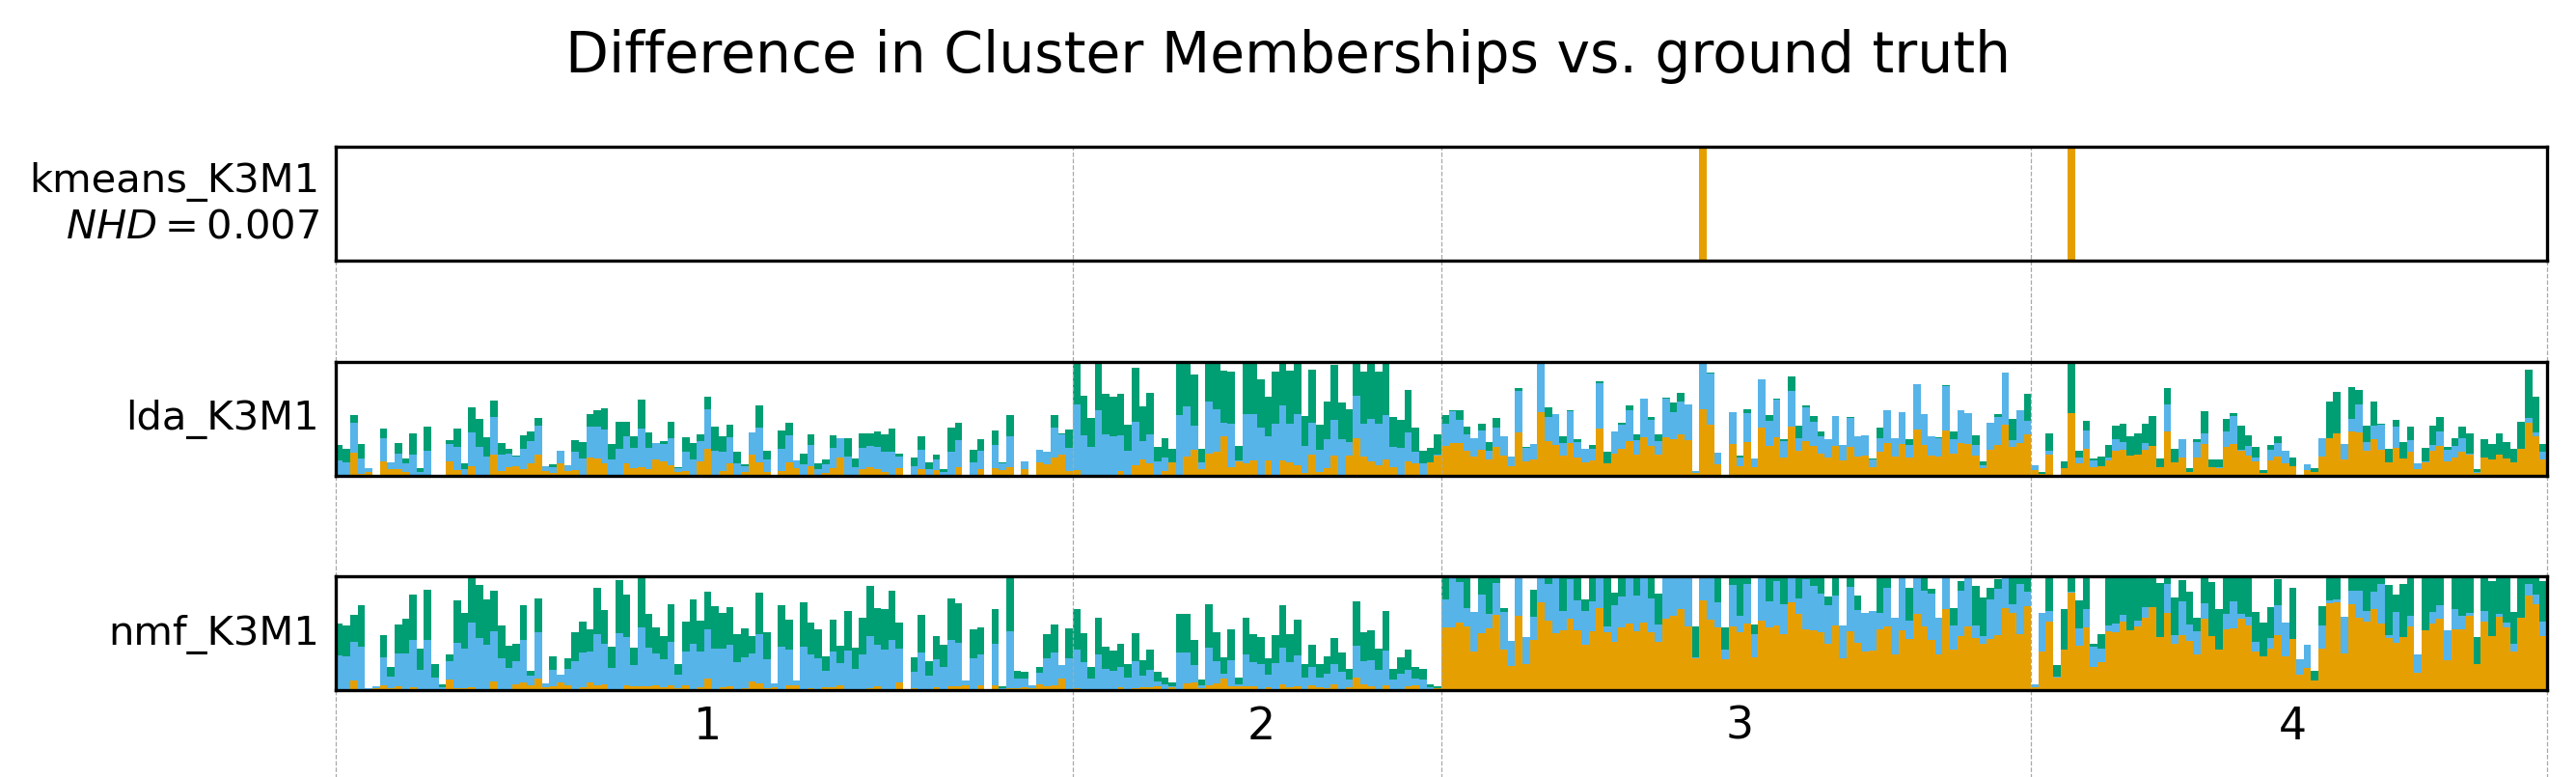

In [52]:
fig = plt.figure(figsize=(9,len(modes_to_plot)), dpi=300)
gs = fig.add_gridspec(len(modes_to_plot)+1, 1, width_ratios=[1])

for i, mode in enumerate(modes_to_plot[1:]):
    mode_full_name = f"{mode[0]}_{mode[1]}"

    ax_diff = fig.add_subplot(gs[i])
    # get difference Q matrix for the mode
    diffQ = mat_diffs[mode[0]][mode[1]]
    # calculate normalized Hamming distance (NHD): for hard-clustering only
    nhd = np.sum(np.sum(diffQ, axis=1)>0.5)/diffQ.shape[0]
    # plot difference membership as stacked barplot (structure plot)
    plot_membership(diffQ, default_colors, ax=ax_diff, ylab="", title="", fontsize=14)
    # use the prepared labels instead
    if mode[0]=="kmeans":
        ax_diff.set_ylabel(mode_full_name+"\n$NHD={:.3f}$".format(nhd), fontsize=10, rotation=0, ha='right', va='center')
    else:
        ax_diff.set_ylabel(mode_full_name, fontsize=10, rotation=0, ha='right', va='center')

    # add vertical lines to separate groups based on cell-reorder reference mode
    for v in grp_seps:
        ax_diff.axvline(v, ymin=-1.5, ymax=1, color='darkgray', ls='--', lw=0.3, clip_on=False)
    if i==len(modes_to_plot[1:])-1:
        for v in grp_seps:
            ax_diff.set_xticks(grp_indices)
            ax_diff.set_xticklabels(np.arange(len(grp_lbs))+1, fontsize=11, rotation=0)
            ax_diff.tick_params(axis='x', length=0)  

fig.suptitle(f"Difference in Cluster Memberships vs. ground truth", fontsize=14)    
fig.tight_layout()

### Model Comparison w.r.t. Reference Annotations
Besides comparing amongst aligned clustering results, we can also compare them with the reference annotations (e.g., ground truth labels, if given).

We can also analyze and compare the associated feature metrics (if using mixed-membership clustering) across multiple models. 

Here we show how to compare results from model NMF and model LDA in our toy dataset.

In [53]:
annotation_group_indices = aoc.get_group_indices(truth_labels)
annotation_group_sizes = aoc.compute_group_sizes(truth_labels)
mode_sizes = aoc.get_mode_sizes(comp_res)

We can compute difference against reference mode for data points in each annotation label group.


In [54]:
ref_mode = "ground.truth_ground.truth"

modes_total_diff, modes_group_diff = aoc.compute_all_mode_diffs(
    comp_results = comp_res, 
    ref_mode = ref_mode,
    pair_mappings = pair_mappings,
    annotation_labels = truth_labels,
    aggregation = "sum"
)
df_mode_group_diff = aoc.build_diff_df(modes_group_diff)
df_mode_group_diff.head()

,0,1,2,3
ground.truth_ground.truth,0.000000e+00,0.000000e+00,0.0000,0.000000
kmeans_K3M1,2.000000e-09,2.000000e-09,0.0125,0.014286
kmeans_K4M1,3.000000e-09,3.000000e-09,0.3500,0.200000
kmeans_K5M1,3.000000e-09,4.000000e-09,0.3500,0.200000
kmeans_K5M2,3.000000e-09,4.000000e-09,0.4125,0.142857


Now let's visualize this in a heatmap.

2026-03-29 23:17:32 - INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-29 23:17:32 - INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


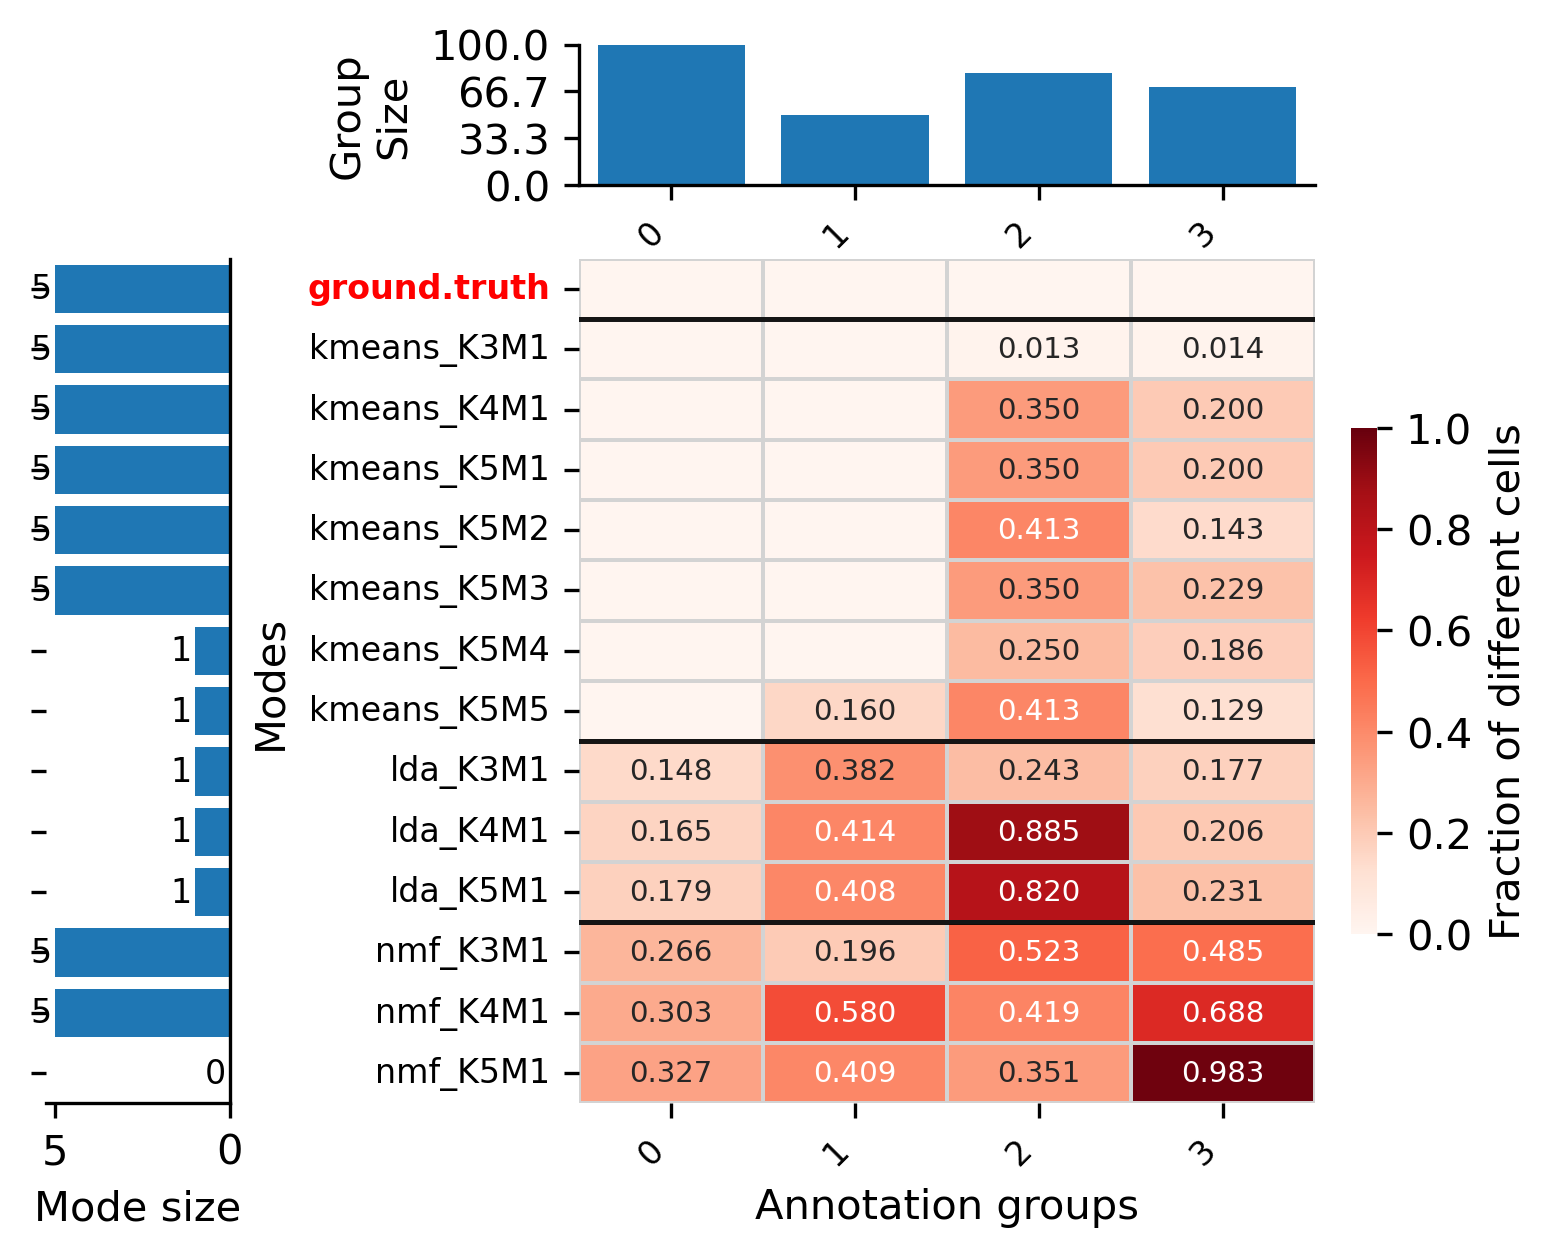

In [55]:
fig, axes = aoc.plot_group_diff(
    df_mode_group_diff,
    mode_sizes=mode_sizes,
    annotation_group_sizes=annotation_group_sizes,
    ref_mode=ref_mode,
    figsize=(5,4),
    top_ylabel="Group\nSize",
    top_round_to=50,
)
# rename mode labels
modes = comp_res.full_mode_names
modes[0] = 'ground.truth'
axes["heatmap"].set_yticklabels(modes, fontsize=8, ha='right')
pass


We can also subset to certain modes, and only show the heatmap (and without values on top).

Text(0.5, 1.15, 'Difference in Annotation Group \n(Selected Modes)')

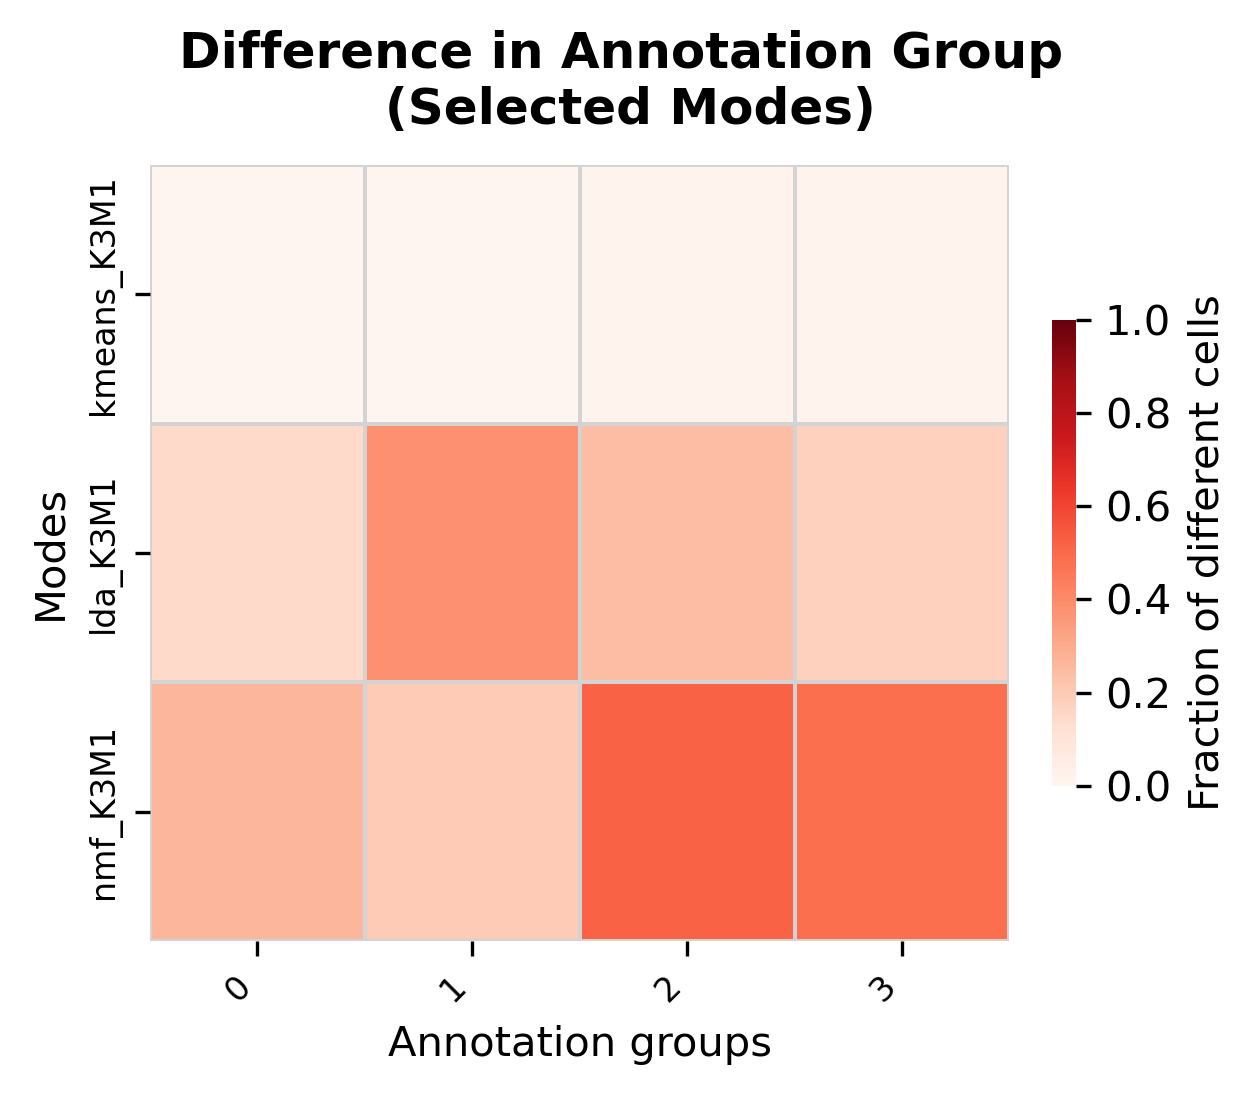

In [56]:
# subset to major modes only
selected_modes = ['kmeans_K3M1', 'lda_K3M1', 'nmf_K3M1']
# annot_sig = 

fig, axes = aoc.plot_group_diff(
    df_mode_group_diff.loc[selected_modes],
    mode_sizes=mode_sizes.loc[selected_modes],
    annotation_group_sizes=annotation_group_sizes,
    ref_mode=ref_mode,
    add_model_separators=False,
    annot=False,
    show_top=False,
    show_left=False,
    figsize=(4,3),
)
fig.suptitle("Difference in Annotation Group \n(Selected Modes)", fontsize=12, weight='bold', y=1.15)
